In [55]:
#df = pd.read_csv("../2026-02-QD_edited.csv")
macro_fred_df = pd.read_csv("../2026-02-MD_edited.csv")
cc_risk_df = pd.read_csv("../credit_risk_dataset.csv")

###### Imports (collapse)

In [111]:
# OS
import os

# pythonic handling
import pandas as pd
import numpy as np
from tqdm import tqdm

# visuals
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# models, datasets
import sklearn
import kagglehub
from sklearn import decomposition, linear_model, metrics

from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, LeaveOneOut
from sklearn.metrics import make_scorer

In [ ]:
'''!pip install statsmodels
!pip install openpyxl'''

In [174]:
from statsmodels.tsa.stattools import adfuller
from scipy.stats import randint, uniform
#from fredmd_transform import transform_fredmd
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# Milestone 4 Notebook

## Functions Sections

### Argument to be made ... (micro dataset to macro time series dataset)

* If interest rate is a top predictor of default → macro equivalent is FEDFUNDS, GS10, or TB3MS (rate environment drives affordability stress)
*  If income is a top predictor → macro equivalent is RPI, PAYEMS, or W875RX1 (aggregate income/employment conditions)
*  If home ownership matters → macro equivalent is HOUST, PERMIT (housing market conditions) or REALLN (real estate lending)
*  If previous default flag matters → macro equivalent is BUSLOANS, NONREVSL, DTCTHFNM (aggregate credit stress indicators)
* If loan-to-income ratio matters → macro equivalent is CONSPI (consumer credit to personal income ratio — this one is actually a direct analog)

The analysis made in the micro econ dataset inform target variable selection in the macro econ dataset. This is a *bottoms-up* argument.

Things to consider:
* Direction of causality — your cross-sectional model shows correlation, not causation. A reviewer might push back that macro conditions cause the micro factors, not the other way around. You'd want to frame it as "these micro factors are the transmission channel through which macro conditions affect default risk"
* Variable selection method matters — if you use something interpretable like logistic regression with coefficients, or SHAP values from a tree model, your argument is much cleaner than just saying "this variable ranked highly"
* CONSPI deserves special attention — it's literally the ratio of nonrevolving consumer credit to personal income, which is almost a direct macro translation of your loan-to-income ratio feature. That's probably your strongest single bridge between the two datasets

### **Week 1-7**
***

#### 🔢 Univariate Functions

##### Week 1

###### df.describe()

In [ ]:
# Week 1
df = pd.DataFrame([[1, 4], [2, 5], [3, 6], [4, 7]], columns = ['A', 'B'])
df.describe()

,A,B
count,4.000000,4.000000
mean,2.500000,5.500000
std,1.290994,1.290994
min,1.000000,4.000000
25%,1.750000,4.750000
50%,2.500000,5.500000
75%,3.250000,6.250000
max,4.000000,7.000000


##### Week 2

###### df.info()

In [7]:
# Week 2
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       4 non-null      int64
 1   B       4 non-null      int64
dtypes: int64(2)
memory usage: 196.0 bytes


##### Week 3

###### Histogram

<Axes: ylabel='Count'>

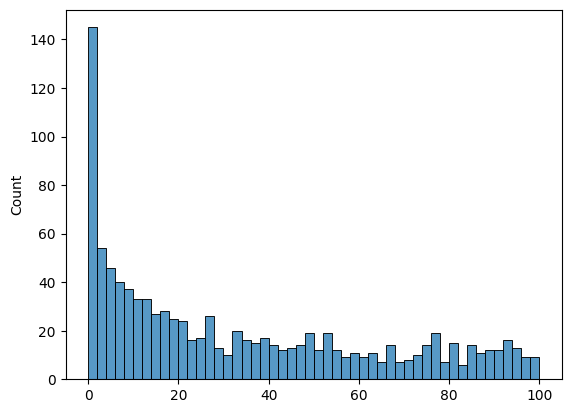

In [14]:
# Week 3
## create random array for visual
np.random.seed(0)
lesson_series = np.round(np.random.random(size = 1000)**2 * 100, 2)
lesson_series[0:10]
## plot histogram (with bins parameters)
sns.histplot(lesson_series, bins = 50)

###### KDE

<Axes: ylabel='Density'>

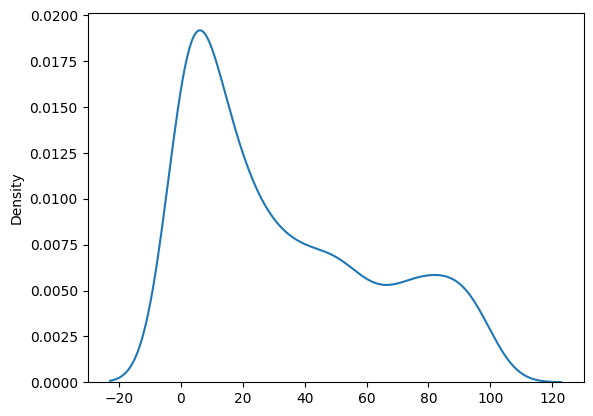

In [ ]:
# Week 3
## Kernel Density Estimate
sns.kdeplot(lesson_series)

###### Boxplot

<Axes: >

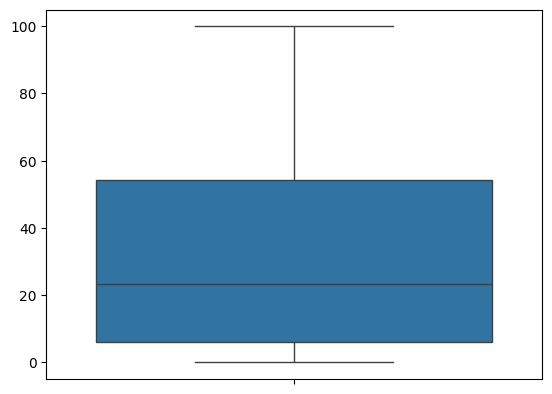

In [19]:
# Week 3
## Boxplot
sns.boxplot(lesson_series)

###### Violinplot

<Axes: >

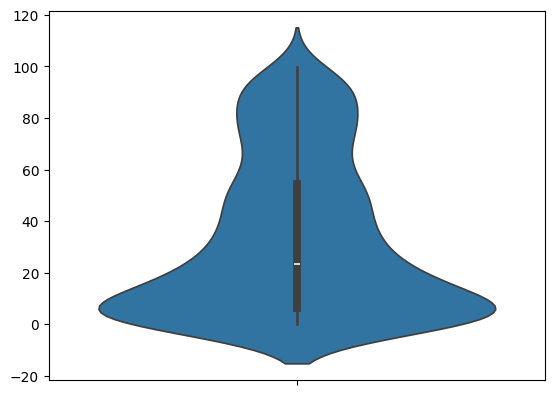

In [20]:
# Week 3
## Violinplot
sns.violinplot(lesson_series)

###### Swarmplot

<Axes: >

/home/codespace/.local/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 8.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


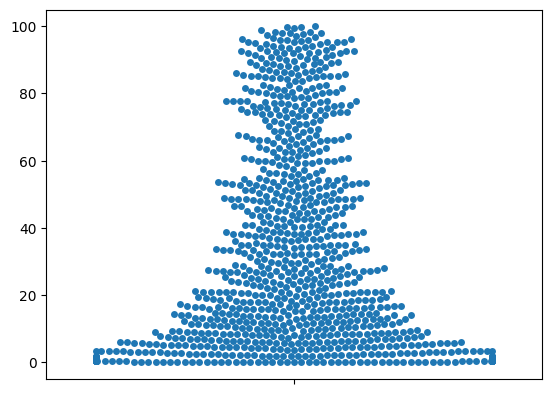

In [21]:
# Week 3
## Swarm plot (like violin but every point shown)
sns.swarmplot(lesson_series)

##### Week 4

###### Histogram again

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

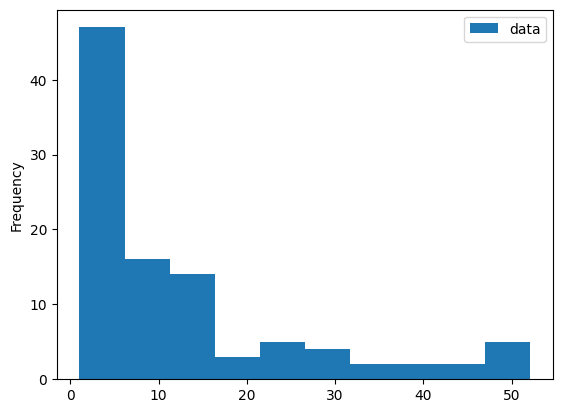

In [22]:
# Week 4
## intialize new df
np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])
## get 75 quantile & make histogram plot
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

###### Boxplot ... again

<Axes: >

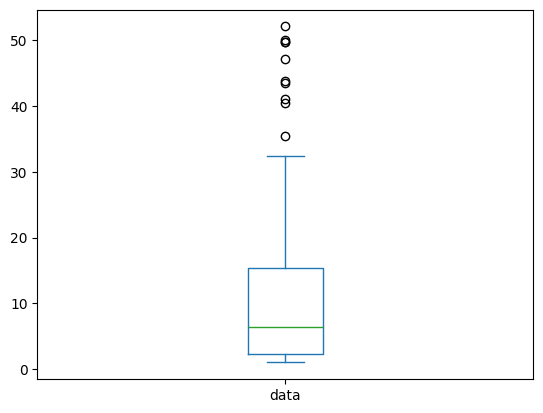

In [23]:
# Week 4
df.plot.box()

#### 🔢 Bivariate Functions

##### Week 5

###### sns Scatterplot

<Axes: >

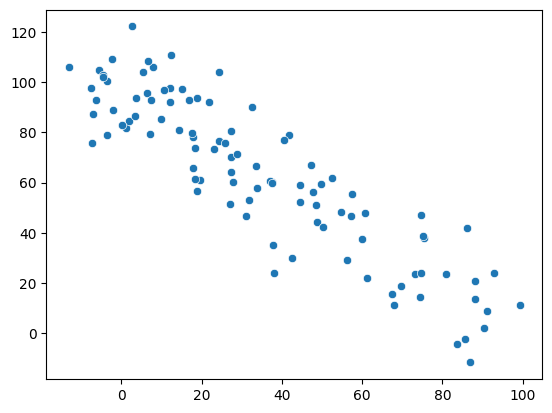

In [6]:
# Week 5
## initialize a set of series
np.random.seed(0)
numpoints = 100
lesson_series_uniform = np.round(np.random.random(size = numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size = numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale = 10, size = numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale = 10, size = numpoints)
## scatterplot
sns.scatterplot(x = lesson_series_skewed, y = lesson_series_reverse)

###### sns Pairplot

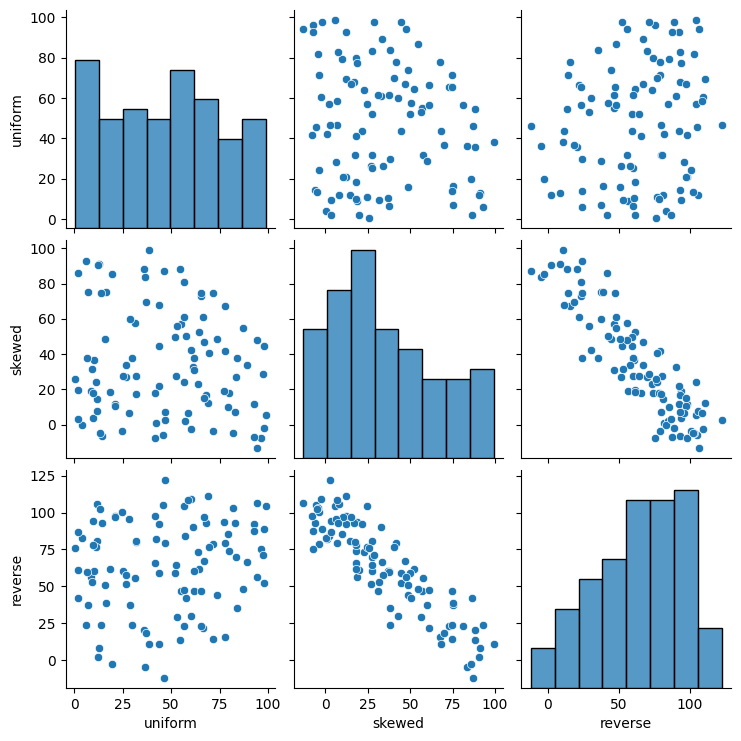

In [7]:
## initialize df from series
df = pd.DataFrame(np.array([lesson_series_uniform, lesson_series_skewed, lesson_series_reverse]).T, columns = ['uniform', 'skewed', 'reverse'])
## pairplot
sns.pairplot(df)

###### df.corr()

In [8]:
print("Correlations:", df.corr())

Correlations:           uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


##### Week 6

###### Line Plots

/tmp/ipykernel_3289/821426618.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

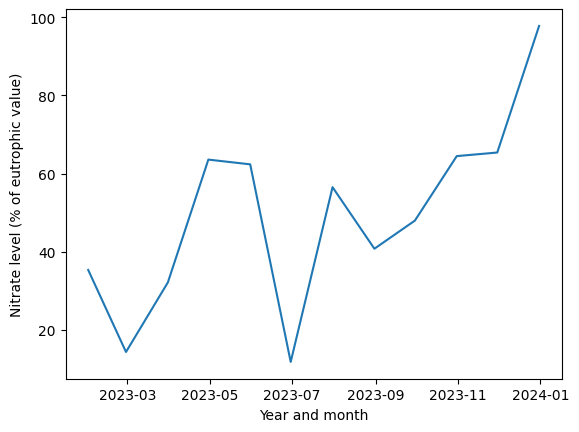

In [13]:
# Week 6
## generate first series
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
## first line plot
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_3289/911992633.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

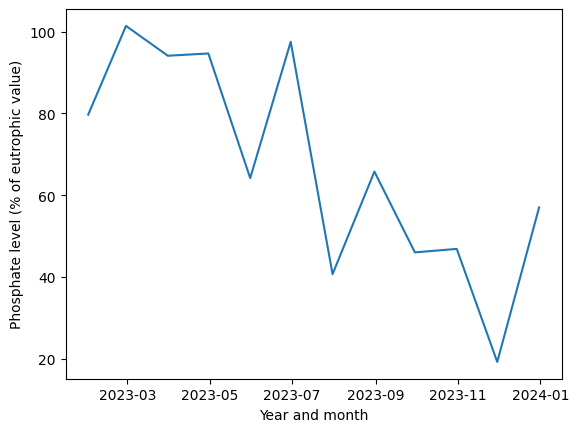

In [14]:
## generate second series
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
## second line plot
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

###### Area Plot

<Axes: >

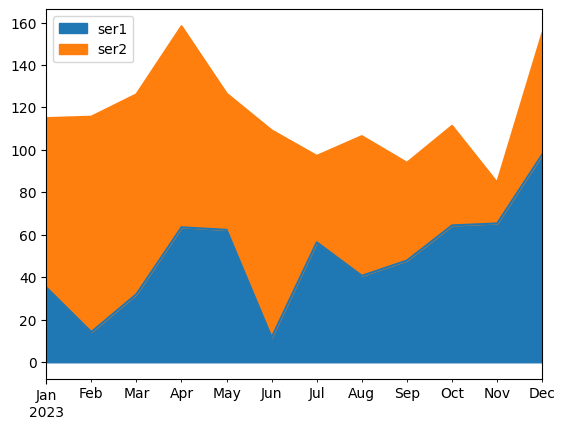

In [15]:
## intialize dataframe from both series
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
## area plot
df.plot.area()

***
### **Week 8-12**

#### 🔢 Multivariate Functions

##### Week 8

###### Heatmap

Text(0.5, 1.0, 'Total traffic tickets by city and year')

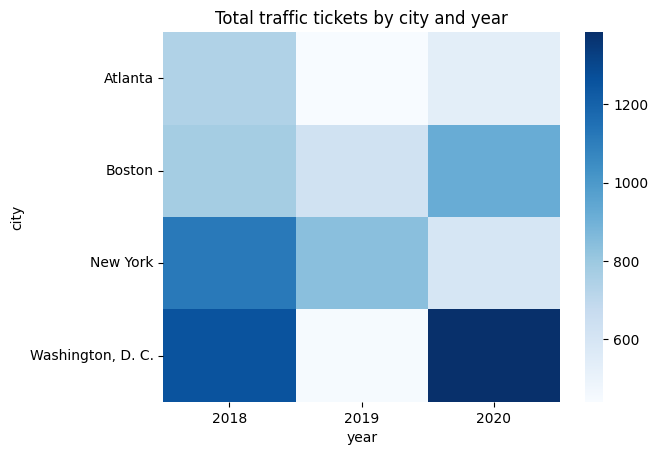

In [ ]:
# Week 8
## intialize series
np.random.seed(0)
num_samples = 100
city_series = np.random.choice(["New York", "Boston", "Atlanta", "Washington, D. C."], size = num_samples)
year_series = np.random.choice([2018, 2019, 2020], size = num_samples)
ticket_series = np.random.randint(50, 150, size = num_samples)
## build df
df = pd.DataFrame({"city": city_series, "year": year_series, "ticket": ticket_series})
pivot = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "sum")
## first heatmap
ax = sns.heatmap(pivot, cmap = "Blues")
ax.set_title("Total traffic tickets by city and year")

Text(0.5, 1.0, 'Average traffic ticket value by city and year')

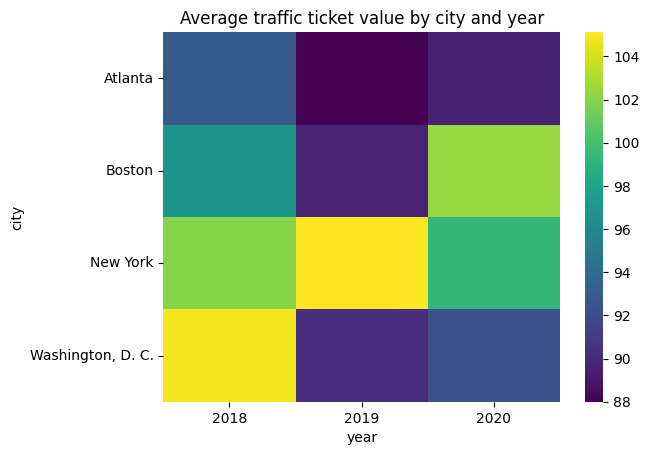

In [18]:
pivot2 = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "mean")
## second heatmap
ax2 = sns.heatmap(pivot2, cmap = "viridis")
ax2.set_title("Average traffic ticket value by city and year")

###### Bubblemap

Text(0, 0.5, 'width of branches')

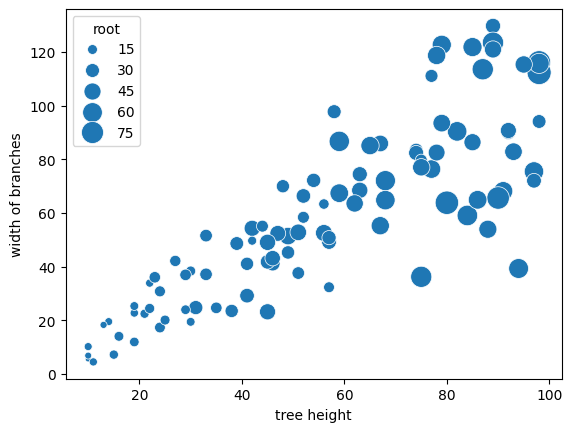

In [19]:
## generate series
np.random.seed(0)
num_samples = 100
height_series = np.random.randint(10, 100, size = num_samples) # tree height
width_series = height_series * np.maximum(np.random.normal(scale = 0.3, loc = 1, size = num_samples), 0.25) # strongly related to height
root_series = height_series * np.maximum(np.random.normal(scale = 0.2, loc = 0.7, size = num_samples), 0.3) # strongly related to height
## make dataframe
df2 = pd.DataFrame({'height': height_series, 'width': width_series, 'root': root_series})
minroot = root_series.min()
maxroot = root_series.max()
maxbubble = 300
## scatterplot
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

###### PCA

Principal Component Analysis can be thought of as a way to use one (or a few) linear combinations of the coordinates in order to explain all of the coordinates.  It is most useful when there are strong correlations between some or all of the coordinates.  Principal Component Analysis can show us which linear combinations are most (and least) useful for explaining the data.

With the trees data, the three values (height, width, and root) are highly correlated.  For this reason, Principal Component Analysis shows that most of the variance can be explained by a single value which is a linear combination of height, width, and root.  What this means is that if the first components_ vector in the code below (the "first principal component") is \[a, b, c\], for some specific numbers a, b, and c, then the value v = a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r), where the mu's are the means, is highly informative about the values of height, width, and root.  In this case, because height, width, and root are so highly correlated, we can almost assume that all of the data is located along an axis defined by the vector \[a, b, c\].  The point v * \[a, b, c\] + (mean vector) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (mean vector) is therefore approximately equal to the data point (height, width, root) in question.  The mean vector is \[mu_h, mu_w, mu_r\].  Importantly, there is still variance unexplained by this one value - just knowing v * \[a, b, c\] does not tell you the height, width, and root with 100% accuracy.  If the second principal component is \[d, e, f\], then we could approximate the tree vector even more accurately as: (height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (mean vector).

The printing of "components_", below, shows the first principal component \[a, b, c\].  If you draw a vector in the direction shown, you will be heading in the direction where the values height, width, and root change most rapidly.  A later computation shows all three principal component vectors.

**Optional exercise for the reader:** show that if all three principal components are included, then equality is exact.  This is going to be true simply because the principal components are orthonormal: the projections onto a complete set of orthonormal vectors always add up to the original vector.

(height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (g * (height - mu_h) + h * (width - mu_w) + i * (root - mu_r)) * \[g, h, i\] + \[mu_h, mu_w, mu_r\].

For this proof, we must use the fact that the principal component vectors are orthonormal.  That is, any pair of them are orthogonal, even with a transpose (ad + be + cf = 0, ag + bh + ci = 0, dg + eh + fi = 0, ab + de + gh = 0, ac + df + gi = 0, bc + ef + hi = 0) and any one of them is a unit vector, even with a transpose (a^2 + b^c + c^2 = 1, d^2 + e^2 + f^2 = 1, g^2 + h^2 + i^2 = 1, a^2 + d^2 + g^2 = 1, b^2 + e^2 + h^2 = 1, c^2 + f^2 + i^2 = 1).  If you write out the equation above as a single vector, then apply the orthonormality rules, you should be able to prove equality.

In [26]:
pca = decomposition.PCA(n_components = 1)
pca.fit(df2)

print(f"The first principal component explains {pca.explained_variance_ratio_[0]} of the variance")
print(f"The components_ vector is [a, b, c] = {pca.components_}")

mu_h, mu_w, mu_r = df2.mean().values

print(f"(height, width, root) is approximately equal to ({pca.components_[0][0]:.2} * (height - {mu_h:.2}) + {pca.components_[0][1]:.2} * (width - {mu_w:.2}) + {pca.components_[0][2]:.2} * (root - {mu_r:.2})) * ({pca.components_[0][0]:.2}, {pca.components_[0][1]:.2}, {pca.components_[0][2]:.2}) + ({mu_h:.2}, {mu_w:.2}, {mu_r:.2})")
print("Examples: (estimating the the vector equals its projection onto the first principal component)")

df_example = df2.copy()
df_example["v"] = pca.components_[0][0] * (df2["height"] - mu_h) + pca.components_[0][1] * (df2["width"] - mu_w) + pca.components_[0][2] * (df2["root"] - mu_r)
df_example["height_est"] = df_example["v"] * pca.components_[0][0] + mu_h
df_example["width_est"] = df_example["v"] * pca.components_[0][1] + mu_w
df_example["root_est"] = df_example["v"] * pca.components_[0][2] + mu_r

print(df_example.iloc[0:5])
print("Means:")
print(f"mu_h = {mu_h:.3}", f"mu_w = {mu_w:.3}", f"mu_r = {mu_r:.3}")

The first principal component explains 0.8686108480944689 of the variance
The components_ vector is [a, b, c] = [[0.59031629 0.71908728 0.36666083]]
(height, width, root) is approximately equal to (0.59 * (height - 5.6e+01) + 0.72 * (width - 5.9e+01) + 0.37 * (root - 3.6e+01)) * (0.59, 0.72, 0.37) + (5.6e+01, 5.9e+01, 3.6e+01)
Examples: (estimating the the vector equals its projection onto the first principal component)
   height       width       root          v  height_est  width_est   root_est
0      54   72.139334  31.517932   6.287751   60.001762  63.563941  38.673095
1      57   49.169527  33.768693  -7.633330   51.783921  53.553468  33.568780
2      74   83.443733  28.770850  25.215680   71.175227  77.174773  45.613225
3      77   76.353866  53.061241  30.794730   74.468631  81.186597  47.658844
4      77  111.095365  26.006307  45.856916   83.360084  92.017624  53.181557
Means:
mu_h = 56.3 mu_w = 59.0 mu_r = 36.4


If we were to choose a second or third component to preserve, that values below show that each would explain a small, additional amount of the variance.  This means that with this particular dataset, we should likely do PCA using only one component and not two.  If the components' explained variances were closer in magnitude to each other, we might have to include two or even all three values to explain the data.

In [27]:
pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df2)

print(pca3.explained_variance_ratio_)
print(pca3.components_)

[0.86861085 0.09414617 0.03724298]
[[ 0.59031629  0.71908728  0.36666083]
 [ 0.32633701 -0.62809127  0.70640322]
 [ 0.73826204 -0.29734633 -0.6054373 ]]


The principal component vectors shown are orthogonal to each other (their dot product is basically zero).  Here, we check that using the first two vectors.

In [28]:
print(np.array(pca3.components_[0]).dot(np.array(pca3.components_[1])))

-1.6653345369377348e-16


We can use the projection onto the first principal component as if it were a new feature.  For instance, we could plot a histogram of the data against the magnitude of the projection onto the first principal component.  In fact, for some purposes, this magnitude (which we have called v) might make a better feature for data analysis than either height, width, or root.  We must subtract off the mean before the dot product; the understanding is that this represents the component of the data relative to the mean.

<Axes: >

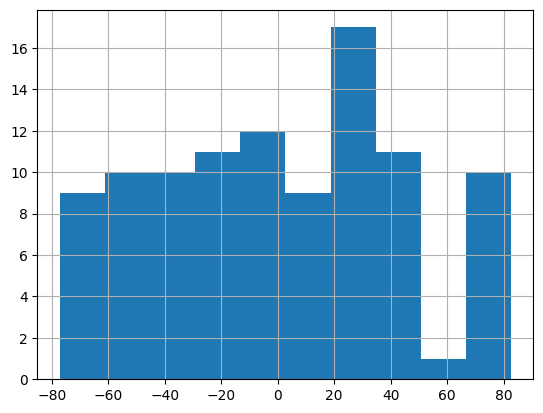

In [29]:
((df2 - df2.mean()).dot(np.array(pca.components_[0]))).hist()

In [30]:
# Showing that this is the same as the value we've called "v"
(df_example["v"] - (df2 - df2.mean()).dot(np.array(pca.components_[0]))).max()

np.float64(0.0)

###### Linear Regression

Now let's run a linear regression model to predict the root from the height and width, as well as predicting the third principal component from the first and second.  Which is easier to predict?

In [31]:
linreg = linear_model.LinearRegression()
linreg.fit(df2[['height', 'width']], df2['root'])
preds = linreg.predict(df2[['height', 'width']])
metrics.mean_squared_error(preds, df2['root']) # Mean squared error as a metric

138.22487356329611

In [32]:
np.corrcoef(preds, df2['root']) # Correlation coefficient as a metric

array([[1.        , 0.79468295],
       [0.79468295, 1.        ]])

Predicting the third principal component from the first and second

In [33]:
first_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[0]))
second_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[1]))
third_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[2]))

In [34]:
linreg_first = linear_model.LinearRegression()
pc_X = np.array([first_principal_component_score, second_principal_component_score]).T
linreg_first.fit(pc_X, third_principal_component_score)
preds = linreg_first.predict(pc_X)
metrics.mean_squared_error(preds, third_principal_component_score) # The mean squared error is a bit smaller here.

78.74928905273173

In [35]:
np.corrcoef(preds, third_principal_component_score) # More importantly, the correlation is basically zero

array([[1.00000000e+00, 1.55375616e-14],
       [1.55375616e-14, 1.00000000e+00]])

Here, we see that the projections of the first two principal components have no ability to predict the projection of the third, when measured by correlation.  This is a special property of principal components.  It is intended to ensure that the each component gives new information not present in the previous components.

The mean_squared_error is misleading - it makes it look like the error is less for the second computation than the first; but the correlation coefficient is giving more useful information here.  We cannot compare the mean squared error for two totally different computations, because mean squared error is highly dependent on the magnitudes of the values in question!

##### Week 9

###### PCA ... again

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

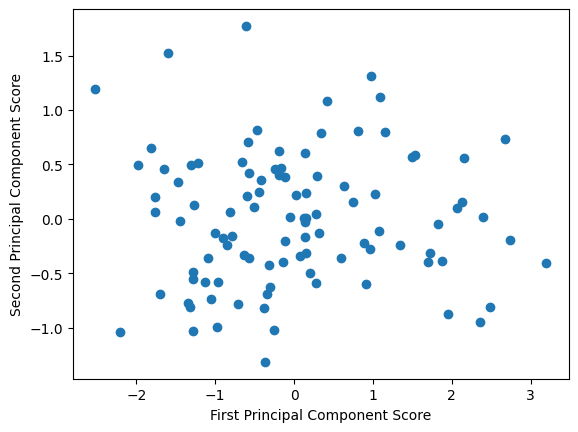

In [36]:
np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)

print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])

plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

##### Week 10

###### Random Forest

Last week, we reviewed one model: linear regression.  This week, we are going to review another, called random forest.  The random forest model builds many decision trees, then averages their estimates to make a prediction.

You will also perform:
* Cross-validation
* Hyperparameter tuning
* A performance metric (root mean squared error)

A random forest is a set of decision trees.  Let's say we use n_estimators = 100 decision trees, and we have ten features.  Then each decision tree is built so that a given branch gets about three (sqrt(10)) features to choose from.  It starts from the top of the tree, selects the best feature, then proceeds to the next nodes.  The best feature is the one that minimizes the mean squared error, which must be computed for both branches, weighted according to the probability of each branch, and then summed over both branches.

Here, we build three series of random numbers between 0 and 1.  We use a somewhat arbitrary formula to construct the synthetic data.  The fourth value (the target) equals the first series minus twice the second, with the whole then being multiplied by the third series.  If we stopped here, the target would be completely dependent on the three feature series - it would be easy to predict.  However, we then add a random normal distribution to make the prediction harder.

There are a train series and a test series, with different features ("a" and "b"), and with different random normal data added.  This tests whether our model can predict new data.  We fit to the "a" features using the train_target, then predict the test_target using the "b" features.

In [38]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

As expected, the RMSE is smallest when predicting the training data, larger when predicting the testing data, and largest when comparing random (shuffled) data instead of using a prediction.  In the last case, there is no attempt to make a good prediction.  The small RMSE when predicting the training data indicates that the model has "memorized" the training data to some degree.

In [39]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rf.predict(train_df.values), train_target))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rf.predict(test_df.values), test_target))

test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.40446903790544014
RMSE when predicting testing data:
1.0666204347667474
RMSE with random predictions:
5.262103337484077


Next, we perform a Grid Search over various parameters.  We've used a small number of parameters here, but you could add more.  The first parameter, n_estimators, shows the number of decision trees in the random forest.  The second, max_depth, is the maximum depth of each tree.  By picking three n_estimators values (10, 33, 100) and three max_depth values (2, 4, None), we allow for nine parameter combinations.  For example, (n_estimators = 10, max_depth = 2) is a combination.  The grid search tries all nine combinations and uses cross validation to choose the best one.  This is done below.

###### Cross Validation

Cross validation is a way to find out which parameter combination is the best.  With 5-fold cross validation (the default) we divide the data into five equal-sized groups.  Four of them are used as training data and the fifth is testing data.  The score (in this case the root mean squared error) on the testing data is recorded.  This is done for each split: that is, each fifth is taken out and used as testing data; then, the five root mean squared errors (from taking out the five fifths, one at a time) are averaged.

We now have root mean squared error value for each parameter combination, allowing us to choose the best combination.

In [40]:
np.random.seed(0)
gcv = GridSearchCV(estimator = RandomForestRegressor(), param_grid = {"n_estimators": [10, 33, 100], "max_depth": [2, 4, None]}, \
                   scoring = "neg_root_mean_squared_error")
gcv.fit(train_df.values, train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'n_estimators': [10, 33, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [41]:
print(gcv.best_estimator_)
print(gcv.best_params_)
print(gcv.best_score_)

RandomForestRegressor()
{'max_depth': None, 'n_estimators': 100}
-1.0851425903159186


In [42]:
gcv.cv_results_["mean_test_score"] # There are nine scores, one for each of the 3 x 3 hyperparameter combinations

array([-2.27296628, -2.26369708, -2.26370023, -1.56063403, -1.52732923,
       -1.52615891, -1.12289873, -1.09373829, -1.08514259])

Why does n_estimators grow like 10, 33, 100 instead of like 1, 50, 100?

First of all, we can make it grow however we want.  The question is why we chose 10, 33, 100.  The idea here is that when you have no idea what is the appropriate number, you should pick guesses that grow exponentially.  For example, suppose you are trying to guess the height of a particular tree.  You look online and find that redwoods grow to 400 feet high, while bonsai trees may be as short as six inches.  If you get three guesses, you could guess: one foot, 200 feet, 400 feet.  These guesses would be linearly spaced out.  However, the 200 foot guess feels wrong - it's still very tall.  Most trees don't grow that tall.  Instead, let's make a geometric progression:

In [43]:
list(map(round, [400**0, 400**0.25, 400**0.5, 400**0.75, 400*1]))

[1, 4, 20, 89, 400]

Now the guesses are four feet, 20 feet, and 89 feet.  (We'll drop the initial 1 and the final 400.) That feels more plausible: the middle value, 20 feet, is representative of many actual trees in a way that the middle 200 foot guess wasn't.

##### Week 11

###### Random Forest ... again

In [44]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [45]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

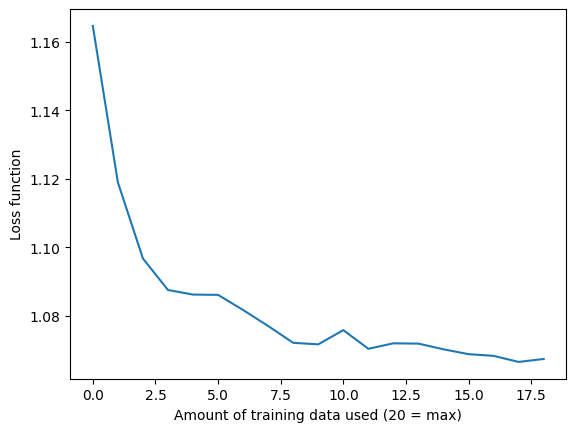

In [46]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [47]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

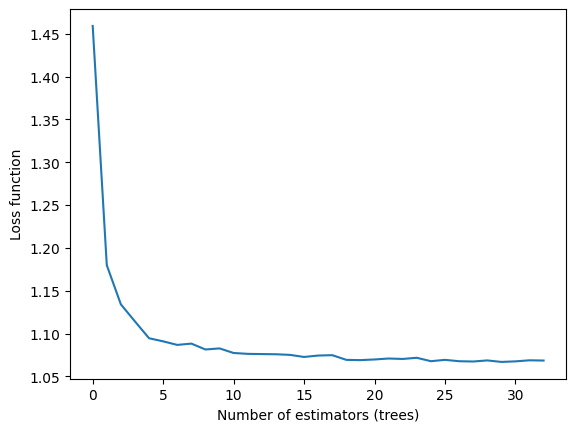

In [48]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

##### Week 12

Text(0, 0.5, 'Number of visitors')

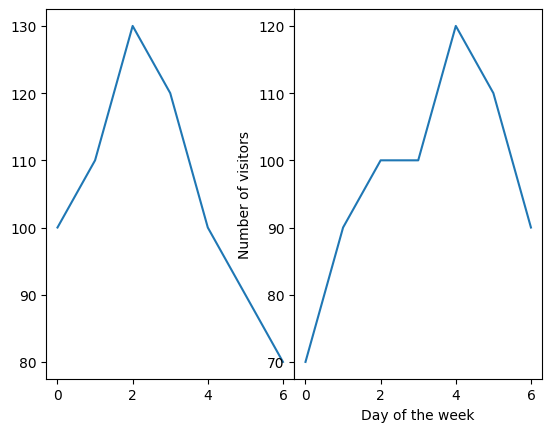

In [49]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Text(0, 0.5, 'Number of visitors')

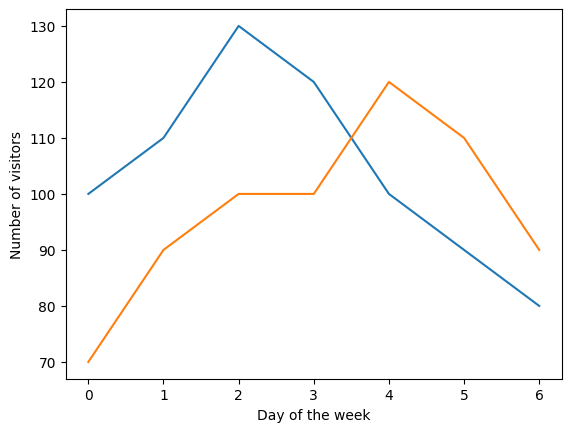

In [50]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

### 2026-02 FRED-MD (transformations)

###### Stationary transformations

In [56]:
"""
FRED-MD Stationarity Transformations
Based on McCracken & Ng (2016) tcode specification.

Transformation codes (tcode):
    1 - Level (no transformation)
    2 - First difference: Δx_t = x_t - x_{t-1}
    3 - Second difference: Δ²x_t = Δx_t - Δx_{t-1}
    4 - Log: log(x_t)
    5 - First difference of log (growth rate): Δlog(x_t) = log(x_t) - log(x_{t-1})
    6 - Second difference of log: Δ²log(x_t)
    7 - First difference of percent change: Δ(x_t/x_{t-1} - 1)

Usage:
    import pandas as pd
    df = pd.read_csv("FRED_MD.csv")
    df_transformed = transform_fredmd(df)
"""

import numpy as np
import pandas as pd


# -------------------------------------------------------------------
# tcode assignments for each FRED-MD variable (McCracken & Ng 2016)
# -------------------------------------------------------------------
TCODES = {
    "RPI": 5, "W875RX1": 5, "DPCERA3M086SBEA": 5, "CMRMTSPLx": 5,
    "RETAILx": 5, "INDPRO": 5, "IPFPNSS": 5, "IPFINAL": 5,
    "IPCONGD": 5, "IPDCONGD": 5, "IPNCONGD": 5, "IPBUSEQ": 5,
    "IPMAT": 5, "IPDMAT": 5, "IPNMAT": 5, "IPMANSICS": 5,
    "IPB51222S": 5, "IPFUELS": 5, "CUMFNS": 2,
    "HWI": 2, "HWIURATIO": 2, "CLF16OV": 5, "CE16OV": 5,
    "UNRATE": 2, "UEMPMEAN": 2, "UEMPLT5": 5, "UEMP5TO14": 5,
    "UEMP15OV": 5, "UEMP15T26": 5, "UEMP27OV": 5, "CLAIMSx": 5,
    "PAYEMS": 5, "USGOOD": 5, "CES1021000001": 5, "USCONS": 5,
    "MANEMP": 5, "DMANEMP": 5, "NDMANEMP": 5, "SRVPRD": 5,
    "USTPU": 5, "USWTRADE": 5, "USTRADE": 5, "USFIRE": 5,
    "USGOVT": 5, "CES0600000007": 1, "AWOTMAN": 2, "AWHMAN": 1,
    "HOUST": 4, "HOUSTNE": 4, "HOUSTMW": 4, "HOUSTS": 4, "HOUSTW": 4,
    "PERMIT": 4, "PERMITNE": 4, "PERMITMW": 4, "PERMITS": 4, "PERMITW": 4,
    "ACOGNO": 5, "AMDMNOx": 5, "ANDENOx": 5, "AMDMUOx": 5,
    "BUSINVx": 5, "ISRATIOx": 2,
    "M1SL": 6, "M2SL": 6, "M2REAL": 5, "BOGMBASE": 6,
    "TOTRESNS": 6, "NONBORRES": 7, "BUSLOANS": 6, "REALLN": 6,
    "NONREVSL": 6, "CONSPI": 2,
    "S&P 500": 5, "S&P div yield": 2, "S&P PE ratio": 5,
    "FEDFUNDS": 2, "CP3Mx": 2, "TB3MS": 2, "TB6MS": 2,
    "GS1": 2, "GS5": 2, "GS10": 2, "AAA": 2, "BAA": 2,
    "COMPAPFFx": 1, "TB3SMFFM": 1, "TB6SMFFM": 1,
    "T1YFFM": 1, "T5YFFM": 1, "T10YFFM": 1, "AAAFFM": 1, "BAAFFM": 1,
    "TWEXAFEGSMTHx": 5, "EXSZUSx": 5, "EXJPUSx": 5,
    "EXUSUKx": 5, "EXCAUSx": 5,
    "WPSFD49207": 6, "WPSFD49502": 6, "WPSID61": 6, "WPSID62": 6,
    "OILPRICEx": 6, "PPICMM": 6, "CPIAUCSL": 6, "CPIAPPSL": 6,
    "CPITRNSL": 6, "CPIMEDSL": 6, "CUSR0000SAC": 6, "CUSR0000SAD": 6,
    "CUSR0000SAS": 6, "CPIULFSL": 6, "CUSR0000SA0L2": 6,
    "CUSR0000SA0L5": 6, "PCEPI": 6, "DDURRG3M086SBEA": 6,
    "DNDGRG3M086SBEA": 6, "DSERRG3M086SBEA": 6,
    "CES0600000008": 6, "CES2000000008": 6, "CES3000000008": 6,
    "UMCSENTx": 2, "DTCOLNVHFNM": 6, "DTCTHFNM": 6,
    "INVEST": 6, "VIXCLSx": 1,
}

TCODE_LABELS = {
    1: "Level (no transformation)",
    2: "First difference",
    3: "Second difference",
    4: "Log",
    5: "First difference of log (growth rate)",
    6: "Second difference of log",
    7: "First difference of percent change",
}


# -------------------------------------------------------------------
# Single-series transformation
# -------------------------------------------------------------------
def _apply_tcode(series: pd.Series, tcode: int) -> pd.Series:
    """
    Apply a single tcode transformation to a pandas Series.

    Parameters
    ----------
    series : pd.Series
        Raw data series (numeric).
    tcode : int
        Transformation code 1-7.

    Returns
    -------
    pd.Series
        Transformed series (same index, NaNs introduced where needed).
    """
    x = series.astype(float)

    if tcode == 1:
        # Level — no change
        return x

    elif tcode == 2:
        # First difference
        return x.diff()

    elif tcode == 3:
        # Second difference
        return x.diff().diff()

    elif tcode == 4:
        # Natural log
        return np.log(x)

    elif tcode == 5:
        # First difference of log (approximate % growth rate)
        return np.log(x).diff()

    elif tcode == 6:
        # Second difference of log
        return np.log(x).diff().diff()

    elif tcode == 7:
        # First difference of percent change
        pct = x.pct_change()
        return pct.diff()

    else:
        raise ValueError(f"Unknown tcode: {tcode}. Must be 1-7.")


# -------------------------------------------------------------------
# Full dataset transformation
# -------------------------------------------------------------------
def transform_fredmd(
    df: pd.DataFrame,
    date_col: str = "sasdate",
    tcodes: dict = None,
    drop_first_rows: int = 2,
) -> pd.DataFrame:
    """
    Transform a raw FRED-MD DataFrame to stationarity using official tcodes.

    Parameters
    ----------
    df : pd.DataFrame
        Raw FRED-MD data. Expects a date column (sasdate) and one column
        per variable. The first row of the actual CSV is the tcode row —
        drop it before passing if you loaded the CSV directly with pandas.
    date_col : str
        Name of the date column. Default: "sasdate".
    tcodes : dict, optional
        Custom {variable: tcode} mapping. Defaults to the official TCODES
        from McCracken & Ng (2016). Useful for overriding individual series.
    drop_first_rows : int
        Number of leading rows to drop after transformation (they will be
        NaN due to differencing). Default: 2 (safe for tcode 6 & 7).

    Returns
    -------
    pd.DataFrame
        Transformed DataFrame with sasdate preserved as-is and all other
        columns transformed. Leading NaN rows are dropped.

    Example
    -------
        import pandas as pd
        raw = pd.read_csv("current.csv")

        # The first data row in FRED-MD CSVs is the tcode row — remove it
        raw = raw[raw[\"sasdate\"] != \"transform\"].copy()
        raw = raw.reset_index(drop=True)

        transformed = transform_fredmd(raw)
        print(transformed.head())
    """
    if tcodes is None:
        tcodes = TCODES

    result = pd.DataFrame()

    if date_col in df.columns:
        result[date_col] = df[date_col].values

    skipped = []
    for col in df.columns:
        if col == date_col:
            continue

        if col not in tcodes:
            skipped.append(col)
            result[col] = df[col]
            continue

        tcode = tcodes[col]
        result[col] = _apply_tcode(df[col], tcode).values

    if skipped:
        print(f"[Warning] No tcode found for {len(skipped)} column(s), left as-is: {skipped}")

    if drop_first_rows > 0:
        result = result.iloc[drop_first_rows:].reset_index(drop=True)

    return result


# -------------------------------------------------------------------
# Convenience helper — transform a single named variable
# -------------------------------------------------------------------
def transform_variable(series: pd.Series, variable_name: str, tcodes: dict = None) -> pd.Series:
    """
    Transform a single FRED-MD variable by name.

    Parameters
    ----------
    series : pd.Series
        Raw data for the variable.
    variable_name : str
        FRED-MD variable name (used to look up its tcode).
    tcodes : dict, optional
        Custom tcode mapping. Defaults to official TCODES.

    Returns
    -------
    pd.Series
        Transformed series.

    Example
    -------
        transformed_cpi = transform_variable(df["CPIAUCSL"], "CPIAUCSL")
    """
    if tcodes is None:
        tcodes = TCODES

    if variable_name not in tcodes:
        raise KeyError(
            f"'{variable_name}' not found in tcode map. "
            f"Pass a custom tcodes dict or check the variable name."
        )

    tcode = tcodes[variable_name]
    print(f"{variable_name}: applying tcode {tcode} — {TCODE_LABELS[tcode]}")
    return _apply_tcode(series, tcode)


# -------------------------------------------------------------------
# Quick demo when run as a script
# -------------------------------------------------------------------
if __name__ == "__main__":
    # Synthetic demo — replace with your actual FRED-MD CSV path
    np.random.seed(42)
    n = 60
    dates = pd.date_range("1990-01", periods=n, freq="MS").strftime("%m/%d/%Y")

    demo_df = pd.DataFrame({
        "sasdate": dates,
        "CPIAUCSL": 130 + np.cumsum(np.random.normal(0.3, 0.1, n)),
        "UNRATE":    5  + np.cumsum(np.random.normal(0,   0.1, n)),
        "FEDFUNDS":  4  + np.cumsum(np.random.normal(0,   0.05, n)),
        "INDPRO":    90 + np.cumsum(np.random.normal(0.2, 0.3, n)),
        "S&P 500":  400 + np.cumsum(np.random.normal(1,   5,   n)),
    })

    print("=== Raw data (first 5 rows) ===")
    print(demo_df.head(), "\n")

    transformed = transform_fredmd(demo_df)

    print("=== Transformed data (first 5 rows) ===")
    print(transformed.head(), "\n")

    print("=== Single variable example: CPIAUCSL ===")
    cpi_t = transform_variable(demo_df["CPIAUCSL"], "CPIAUCSL")
    print(cpi_t.head(10))

=== Raw data (first 5 rows) ===
      sasdate  CPIAUCSL  UNRATE  FEDFUNDS  INDPRO  S&P 500
0  01/01/1990  130.3497  4.9521    4.0396 90.3877 397.0374
1  02/01/1990  130.6358  4.9335    3.9941 90.3306 397.4637
2  03/01/1990  131.0006  4.8229    4.0642 90.2093 400.9887
3  04/01/1990  131.4529  4.7033    3.9941 90.5540 406.3174
4  05/01/1990  131.7295  4.7845    4.0235 90.6870 401.3159 

=== Transformed data (first 5 rows) ===
      sasdate  CPIAUCSL  UNRATE  FEDFUNDS  INDPRO  S&P 500
0  03/01/1990    0.0006 -0.1106    0.0701 -0.0013   0.0088
1  04/01/1990    0.0007 -0.1196   -0.0701  0.0038   0.0132
2  05/01/1990   -0.0013  0.0813    0.0293  0.0015  -0.0124
3  06/01/1990   -0.0000  0.1356    0.1095  0.0046  -0.0017
4  07/01/1990    0.0014 -0.0072   -0.0495  0.0037  -0.0034 

=== Single variable example: CPIAUCSL ===
CPIAUCSL: applying tcode 6 — Second difference of log
0       NaN
1       NaN
2    0.0006
3    0.0007
4   -0.0013
5   -0.0000
6    0.0014
7   -0.0006
8   -0.0009
9    0.0008


In [ ]:
macro_fred_df = transform_fredmd(macro_fred_df)

In [ ]:
def adf_score(series: pd.Series) -> float:
    """
    Run ADF test on a series and return the p-value.
    Returns NaN if the test cannot be run (e.g. too many NaNs).
    """
    clean = series.dropna()
    if len(clean) < 20:
        return np.nan
    try:
        result = adfuller(clean, autolag="AIC")
        return round(result[1], 4)  # p-value
    except Exception:
        return np.nan


def stationarity_report(
    df_raw: pd.DataFrame,
    date_col: str = "sasdate",
    save_path: str = "stationarity_report.xlsx",
) -> pd.DataFrame:
    """
    Compare ADF test p-values before and after FRED-MD transformations.

    Parameters
    ----------
    df_raw    : Raw FRED-MD DataFrame (before transformation)
    date_col  : Name of the date column. Default: 'sasdate'
    save_path : Output Excel file path

    Returns
    -------
    pd.DataFrame with columns:
        Variable      - series name
        ADF_Raw       - p-value on raw series
        ADF_Transformed - p-value on transformed series
        Stationary_Raw        - Yes/No at 5% significance
        Stationary_Transformed - Yes/No at 5% significance

    Interpretation
    --------------
    ADF p-value < 0.05  → reject unit root → series is stationary
    ADF p-value >= 0.05 → fail to reject  → series is non-stationary
    """
    df_transformed = transform_fredmd(df_raw, date_col=date_col)

    records = []
    for col in df_raw.columns:
        if col == date_col:
            continue

        p_raw   = adf_score(df_raw[col])
        p_trans = adf_score(df_transformed[col]) if col in df_transformed.columns else np.nan

        records.append({
            "Variable":               col,
            "ADF p-value (Raw)":      p_raw,
            "ADF p-value (Transformed)": p_trans,
            "Stationary (Raw)":       "Yes" if (p_raw   is not np.nan and p_raw   < 0.05) else "No",
            "Stationary (Transformed)": "Yes" if (p_trans is not np.nan and p_trans < 0.05) else "No",
        })

    report = pd.DataFrame(records)
    _save_report_excel(report, save_path)
    print(f"Stationarity report saved to: {save_path}")
    return report


def _save_report_excel(report: pd.DataFrame, path: str):
    """Style and save the stationarity report as an Excel file."""
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Stationarity Report"

    # --- Styles ---
    thin        = Side(style="thin", color="CCCCCC")
    border      = Border(left=thin, right=thin, top=thin, bottom=thin)
    header_font = Font(name="Arial", bold=True, color="FFFFFF", size=11)
    header_fill = PatternFill("solid", start_color="1F4E79")
    center      = Alignment(horizontal="center", vertical="center")
    alt_fill    = PatternFill("solid", start_color="EBF3FB")
    white_fill  = PatternFill("solid", start_color="FFFFFF")
    green_fill  = PatternFill("solid", start_color="E2EFDA")
    red_fill    = PatternFill("solid", start_color="FCE4D6")

    col_widths  = [22, 22, 26, 20, 24]
    for i, w in enumerate(col_widths, start=1):
        ws.column_dimensions[openpyxl.utils.get_column_letter(i)].width = w

    # --- Header row ---
    for col_idx, col_name in enumerate(report.columns, start=1):
        cell = ws.cell(row=1, column=col_idx, value=col_name)
        cell.font      = header_font
        cell.fill      = header_fill
        cell.alignment = center
        cell.border    = border
    ws.row_dimensions[1].height = 20
    ws.freeze_panes = "A2"

    # --- Data rows ---
    for row_idx, row in enumerate(report.itertuples(index=False), start=2):
        fill = alt_fill if row_idx % 2 == 0 else white_fill
        values = list(row)

        for col_idx, val in enumerate(values, start=1):
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.font      = Font(name="Arial", size=10)
            cell.alignment = center if col_idx > 1 else Alignment(vertical="center")
            cell.border    = border

            # Color-code the Stationary Yes/No columns
            if col_idx in (4, 5):
                if val == "Yes":
                    cell.fill = green_fill
                    cell.font = Font(name="Arial", size=10, color="375623", bold=True)
                elif val == "No":
                    cell.fill = red_fill
                    cell.font = Font(name="Arial", size=10, color="843C0C", bold=True)
                else:
                    cell.fill = fill
            else:
                cell.fill = fill

    wb.save(path)


# --- Example usage ---
if __name__ == "__main__":
    raw = pd.read_csv("../2026-02-MD_edited.csv")
    raw = raw[raw["sasdate"] != "transform"].reset_index(drop=True)

    report = stationarity_report(raw, save_path="stationarity_report.xlsx")
    print(report.head(10))

###### Macro Plots

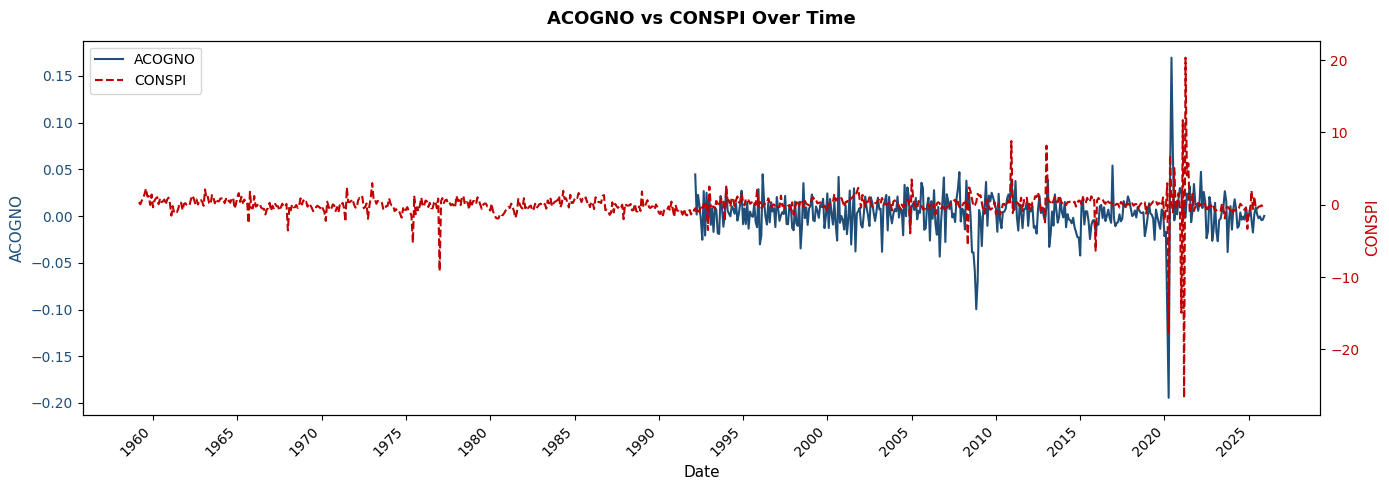

In [73]:
def plot_fredmd_dual(df, var1, var2, date_col="sasdate", figsize=(14, 5)):
    """
    Plot two FRED-MD variables over time on dual y-axes.

    Parameters
    ----------
    df       : transformed FRED-MD DataFrame
    var1     : primary variable (left y-axis)
    var2     : secondary variable (right y-axis)
    date_col : name of the date column (default: 'sasdate')
    figsize  : figure size tuple
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    fig, ax1 = plt.subplots(figsize=figsize)

    # --- Left axis: var1 ---
    color1 = "#1F4E79"
    ax1.plot(df[date_col], df[var1], color=color1, linewidth=1.5, label=var1)
    ax1.set_ylabel(var1, color=color1, fontsize=11)
    ax1.tick_params(axis="y", labelcolor=color1)
    ax1.set_xlabel("Date", fontsize=11)

    # --- Right axis: var2 ---
    ax2 = ax1.twinx()
    color2 = "#C00000"
    ax2.plot(df[date_col], df[var2], color=color2, linewidth=1.5, linestyle="--", label=var2)
    ax2.set_ylabel(var2, color=color2, fontsize=11)
    ax2.tick_params(axis="y", labelcolor=color2)

    # --- Formatting ---
    ax1.xaxis.set_major_locator(mdates.YearLocator(5))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

    plt.title(f"{var1} vs {var2} Over Time", fontsize=13, fontweight="bold", pad=12)
    fig.tight_layout()
    plt.savefig("fredmd_dual_plot.png", dpi=150, bbox_inches="tight")
    plt.show()


# --- Example usage ---
plot_fredmd_dual(macro_fred_df, var1="ACOGNO", var2="CONSPI")

## Analysis Section

In [116]:
macro_fred_df = pd.read_csv("../2026-02-MD_edited.csv")
cc_risk_df = pd.read_csv("../credit_risk_dataset.csv")

In [6]:
pd.options.display.float_format = '{:,.4f}'.format

### Consumer Credit Risk Dataset

#### EDA pre-processing prep

##### Convert categories into numberic and label ordinal, nominal, and binary

In [151]:
# create ordinal number column for loan_grade
mapping = {'A': 1, 'B': 2, 'C': 3,'D': 4, 'E': 5, 'F': 6, 'G': 7}
cc_risk_df['CAT_loan_grade_ordinal'] = cc_risk_df['loan_grade'].map(mapping)

# create binary column flag for cb_person_default_on_file
mapping = {'Y': 1, 'N': 0}
cc_risk_df['CAT_cb_person_default_on_file_binary'] = cc_risk_df['cb_person_default_on_file'].map(mapping)

# create nominal column flag for person_home_ownership
mapping = {'OWN': 1, 'MORTGAGE': 2,'RENT': 3, 'OTHER': 4}
cc_risk_df['CAT_person_home_ownership_nominal'] = cc_risk_df['person_home_ownership'].map(mapping)

# create nominal column flag for loan_intent
mapping = {'DEBTCONSOLIDATION': 1, 'EDUCATION': 2, 'HOMEIMPROVEMENT': 3,'MEDICAL': 4, 'PERSONAL': 5, 'VENTURE': 6}
cc_risk_df['CAT_loan_intent_nominal'] = cc_risk_df['loan_intent'].map(mapping)

##### Drop null: loan_int_rate and person_emp_length (-3,943)

In [152]:
cc_risk_df = cc_risk_df.dropna(subset=['loan_int_rate','person_emp_length'])

##### New integer column for loan_int_rate

In [153]:

cc_risk_df["loan_int_rate_integer"] = np.floor(cc_risk_df['loan_int_rate']).astype(int)
#cc_risk_df["loan_int_rate_rounded"] = np.round(cc_risk_df['loan_int_rate']).astype(int)

#### EDA

##### Null count

In [154]:
cc_risk_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28638 entries, 0 to 32580
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   person_age                            28638 non-null  int64  
 1   person_income                         28638 non-null  int64  
 2   person_home_ownership                 28638 non-null  object 
 3   person_emp_length                     28638 non-null  float64
 4   loan_intent                           28638 non-null  object 
 5   loan_grade                            28638 non-null  object 
 6   loan_amnt                             28638 non-null  int64  
 7   loan_int_rate                         28638 non-null  float64
 8   loan_status                           28638 non-null  int64  
 9   loan_percent_income                   28638 non-null  float64
 10  cb_person_default_on_file             28638 non-null  object 
 11  cb_person_cred_hist_

##### Basic stats

In [155]:
cc_risk_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,CAT_loan_grade_ordinal,CAT_cb_person_default_on_file_binary,CAT_person_home_ownership_nominal,CAT_loan_intent_nominal,loan_int_rate_integer
count,"28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000","28,638.0000"
mean,27.7272,"66,649.3719",4.7887,"9,656.4931",11.0399,0.2166,0.1695,5.7937,2.2282,0.1782,2.4381,3.5313,10.4620
std,6.3104,"62,356.4474",4.1546,"6,329.6834",3.2294,0.4119,0.1064,4.0385,1.1707,0.3827,0.6371,1.7298,3.2614
min,20.0000,"4,000.0000",0.0000,500.0000,5.4200,0.0000,0.0000,2.0000,1.0000,0.0000,1.0000,1.0000,5.0000
25%,23.0000,"39,480.0000",2.0000,"5,000.0000",7.9000,0.0000,0.0900,3.0000,1.0000,0.0000,2.0000,2.0000,7.0000
50%,26.0000,"55,956.0000",4.0000,"8,000.0000",10.9900,0.0000,0.1500,4.0000,2.0000,0.0000,3.0000,4.0000,10.0000
75%,30.0000,"80,000.0000",7.0000,"12,500.0000",13.4800,0.0000,0.2300,8.0000,3.0000,0.0000,3.0000,5.0000,13.0000
max,144.0000,"6,000,000.0000",123.0000,"35,000.0000",23.2200,1.0000,0.8300,30.0000,7.0000,1.0000,4.0000,6.0000,23.0000


##### loan_grade hist

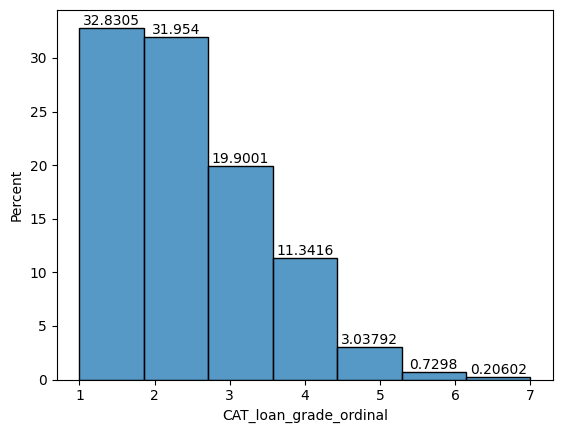

In [156]:
ax = sns.histplot(cc_risk_df['CAT_loan_grade_ordinal'], stat='percent', bins=7)
for container in ax.containers:
    ax.bar_label(container)

##### Default hist

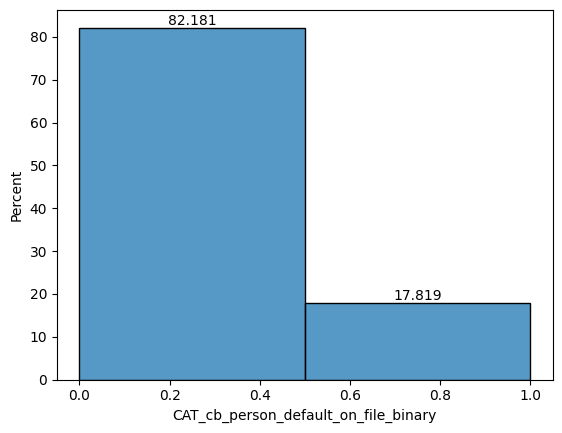

In [157]:
# CAT_cb_person_default_on_file_binary

ax = sns.histplot(cc_risk_df['CAT_cb_person_default_on_file_binary'], stat='percent', bins=2)
for container in ax.containers:
    ax.bar_label(container)

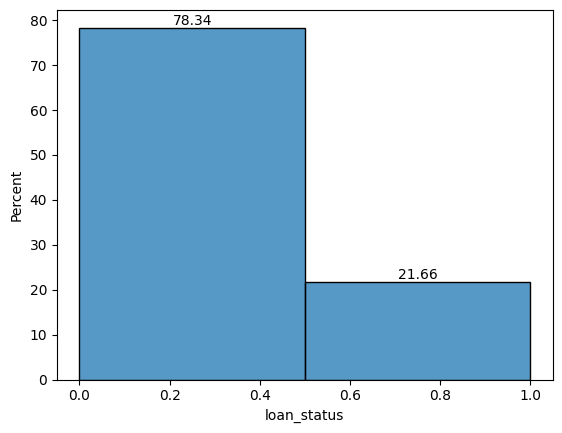

In [158]:
# loan_status

ax = sns.histplot(cc_risk_df['loan_status'], stat='percent', bins=2)
for container in ax.containers:
    ax.bar_label(container)

##### Income boxplot

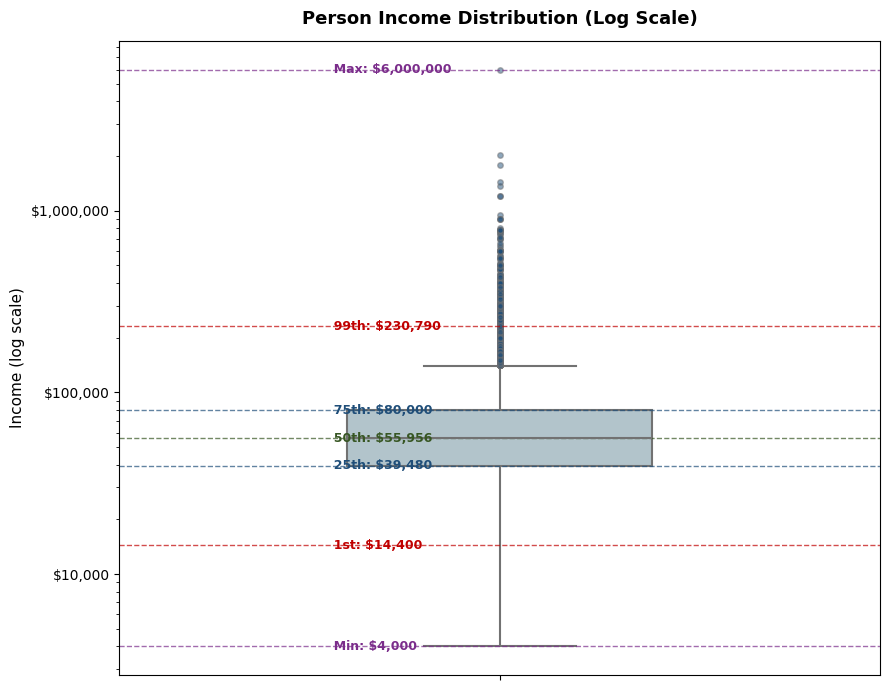

In [159]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.boxplot(data=cc_risk_df, y="person_income", ax=ax,
            color="#AEC6CF", width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='#1F4E79', markersize=4, alpha=0.5))

ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# --- Percentile + min/max labels ---
income = cc_risk_df["person_income"].dropna()

percentiles = {
    "Min":  income.min(),
    "1st":  np.percentile(income, 1),
    "25th": np.percentile(income, 25),
    "50th": np.percentile(income, 50),
    "75th": np.percentile(income, 75),
    "99th": np.percentile(income, 99),
    "Max":  income.max(),
}

colors = {
    "Min":  "#7B2D8B",
    "1st":  "#C00000",
    "25th": "#1F4E79",
    "50th": "#375623",
    "75th": "#1F4E79",
    "99th": "#C00000",
    "Max":  "#7B2D8B",
}

for label, val in percentiles.items():
    ax.axhline(y=val, linestyle="--", linewidth=1, color=colors[label], alpha=0.7)
    ax.text(
        x=0.27,
        y=val,
        s=f"  {label}: ${val:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color=colors[label],
        fontweight="bold",
        transform=ax.get_yaxis_transform()
    )

ax.set_title("Person Income Distribution (Log Scale)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Income (log scale)", fontsize=11)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

##### Loan amount boxplot

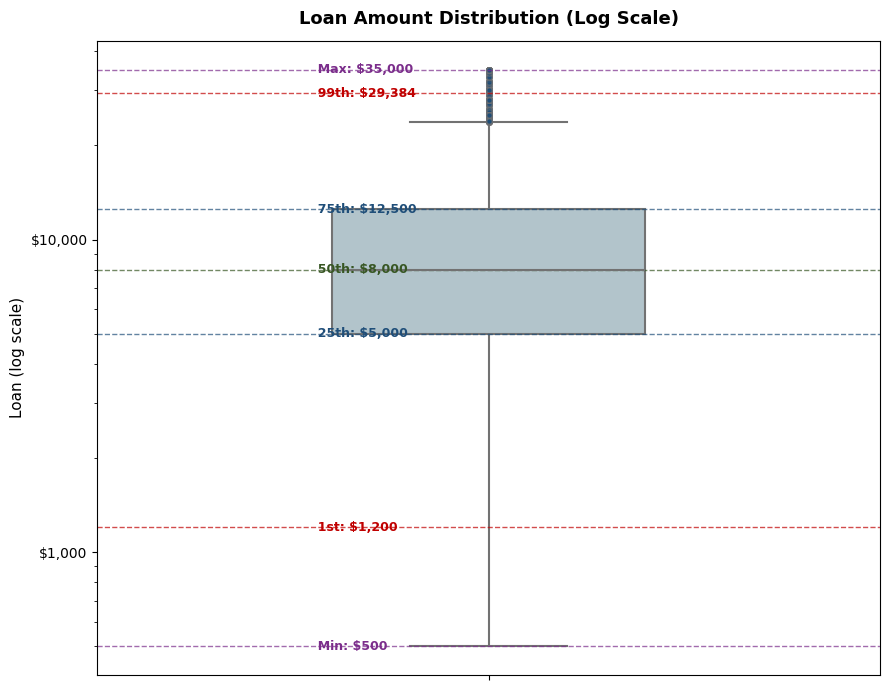

In [160]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.boxplot(data=cc_risk_df, y="loan_amnt", ax=ax,
            color="#AEC6CF", width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='#1F4E79', markersize=4, alpha=0.5))

ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# --- Percentile + min/max labels ---
tick = cc_risk_df["loan_amnt"].dropna()

percentiles = {
    "Min":  tick.min(),
    "1st":  np.percentile(tick, 1),
    "25th": np.percentile(tick, 25),
    "50th": np.percentile(tick, 50),
    "75th": np.percentile(tick, 75),
    "99th": np.percentile(tick, 99),
    "Max":  tick.max(),
}

colors = {
    "Min":  "#7B2D8B",
    "1st":  "#C00000",
    "25th": "#1F4E79",
    "50th": "#375623",
    "75th": "#1F4E79",
    "99th": "#C00000",
    "Max":  "#7B2D8B",
}

for label, val in percentiles.items():
    ax.axhline(y=val, linestyle="--", linewidth=1, color=colors[label], alpha=0.7)
    ax.text(
        x=0.27,
        y=val,
        s=f"  {label}: ${val:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color=colors[label],
        fontweight="bold",
        transform=ax.get_yaxis_transform()
    )

ax.set_title("Loan Amount Distribution (Log Scale)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Loan (log scale)", fontsize=11)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

##### BIVARIATE BELOW

##### Default barplots

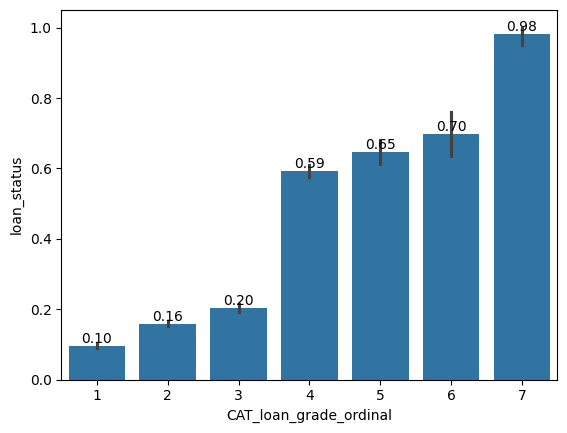

In [161]:
# percentage of loan default in loan grade

ax = sns.barplot(data=cc_risk_df, x="CAT_loan_grade_ordinal", y="loan_status")
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}')

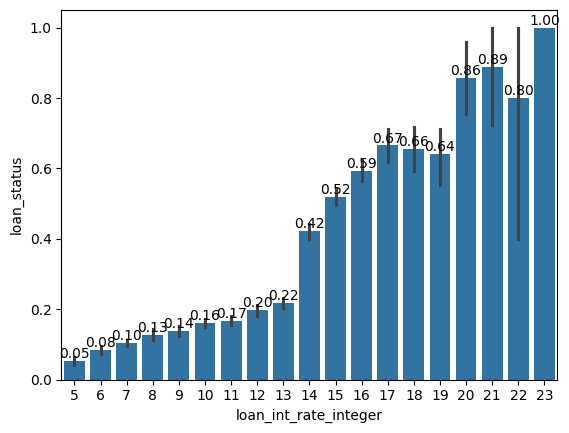

In [162]:
# percentage of loan defaults in interest rate groups

ax = sns.barplot(data=cc_risk_df, x="loan_int_rate_integer", y="loan_status")
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}')

##### Correlation

In [163]:
cc_risk_df_CAT = cc_risk_df.drop(columns=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file'])
cc_risk_df_CAT.corr()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,CAT_loan_grade_ordinal,CAT_cb_person_default_on_file_binary,CAT_person_home_ownership_nominal,CAT_loan_intent_nominal,loan_int_rate_integer
person_age,1.0000,0.1789,0.1658,0.0542,0.0110,-0.0233,-0.0411,0.8595,0.0135,0.0078,-0.0289,0.0364,0.0101
person_income,0.1789,1.0000,0.1368,0.2659,-0.0014,-0.1399,-0.2515,0.1171,0.0014,-0.0027,-0.1267,0.0025,-0.0019
person_emp_length,0.1658,0.1368,1.0000,0.1108,-0.0564,-0.0826,-0.0552,0.1463,-0.0493,-0.0279,-0.1953,0.0210,-0.0563
loan_amnt,0.0542,0.2659,0.1108,1.0000,0.1459,0.1135,0.5774,0.0453,0.1499,0.0403,-0.0789,-0.0033,0.1436
loan_int_rate,0.0110,-0.0014,-0.0564,0.1459,1.0000,0.3393,0.1235,0.0154,0.9335,0.5003,0.1103,-0.0025,0.9961
loan_status,-0.0233,-0.1399,-0.0826,0.1135,0.3393,1.0000,0.3797,-0.0156,0.3797,0.1820,0.2309,-0.0646,0.3393
loan_percent_income,-0.0411,-0.2515,-0.0552,0.5774,0.1235,0.3797,1.0000,-0.0301,0.1258,0.0362,0.0785,0.0004,0.1224
cb_person_cred_hist_length,0.8595,0.1171,0.1463,0.0453,0.0154,-0.0156,-0.0301,1.0000,0.0146,0.0084,-0.0256,0.0360,0.0146
CAT_loan_grade_ordinal,0.0135,0.0014,-0.0493,0.1499,0.9335,0.3797,0.1258,0.0146,1.0000,0.5358,0.0990,-0.0045,0.9330
CAT_cb_person_default_on_file_binary,0.0078,-0.0027,-0.0279,0.0403,0.5003,0.1820,0.0362,0.0084,0.5358,1.0000,0.0483,-0.0024,0.5013


``NOTE:``
loan_int_rate and loan_grade are highly correlated (but loan grade has slightly higher correlation with other variables)



The variables with the best predictive power for "loan_status" are:
* loan_int_rate (or loan_int_rate_integer) -> ~0.3393
* CAT_loan_grade_ordinal -> 0.3797
* loan_percent_income -> 0.3797
* person_income -> -0.1399
* loan_amnt -> 0.1135
* CAT_loan_grade_ordinal -> 0.3797
* CAT_person_home_ownership_nominal -> 0.2309
* CAT_cb_person_default_on_file_binary -> .1820

#### Check and drop nulls

In [164]:
cc_risk_df_CAT.isnull().sum()

person_age                              0
person_income                           0
person_emp_length                       0
loan_amnt                               0
loan_int_rate                           0
loan_status                             0
loan_percent_income                     0
cb_person_cred_hist_length              0
CAT_loan_grade_ordinal                  0
CAT_cb_person_default_on_file_binary    0
CAT_person_home_ownership_nominal       0
CAT_loan_intent_nominal                 0
loan_int_rate_integer                   0
dtype: int64

#### Random Forest

In [168]:
X = cc_risk_df_CAT.drop(columns=['loan_status'])
print(X.shape)
y = cc_risk_df_CAT['loan_status']
print(y.shape)

(28638, 12)
(28638,)


In [169]:
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

##### RF mean sqr error & R^2

In [173]:
def run_random_forest_regressor(X_train, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,       
                                bootstrap = True,         
                                random_state = random_state,
                                cv=5,
                                ccp_alpha=0.0,
                                n_jobs=-1
                               ):
    
    rf_model = RandomForestRegressor(
        n_estimators = n_estimators,
        max_depth = max_depth,
        max_samples = max_samples,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_features = max_features,
        max_leaf_nodes=max_leaf_nodes,
        bootstrap = bootstrap,
        n_jobs = n_jobs,
        random_state = random_state,
        ccp_alpha=ccp_alpha,
    )
    
    # MSE
    neg_mse_scores = cross_val_score(
        rf_model, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=cv, n_jobs=n_jobs
    )

    # R²
    r2_scores = cross_val_score(
        rf_model, X_train, y_train,
        scoring='r2',
        cv=cv, n_jobs=n_jobs
    )

    results = {
        "mean_cv_mse": -np.mean(neg_mse_scores),
        "mean_r2":      np.mean(r2_scores),
        "std_r2":       np.std(r2_scores),
    }

    print(f"MSE       : {results['mean_cv_mse']:.4f}")
    print(f"Mean R²   : {results['mean_r2']:.4f}")
    print(f"Std  R²   : {results['std_r2']:.4f}")

    return results


# --- Example usage ---
results = run_random_forest_regressor(X_train, y_train,
                                      n_estimators=100,
                                      max_depth=None,
                                      min_samples_split=2,
                                      min_samples_leaf=1,
                                      max_samples=None,
                                      max_leaf_nodes=None,
                                      max_features=1.0,
                                      ccp_alpha=0.0)

# Access individually if needed
print(results["mean_cv_mse"])
print(results["mean_r2"])
print(results["std_r2"])

MSE       : 0.0576
Mean R²   : 0.6581
Std  R²   : 0.0204
0.05760832824094282
0.658076822821571
0.02043170156481869


In [171]:
cc_risk_df_CAT['loan_status'].describe()

count   28,638.0000
mean         0.2166
std          0.4119
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000
Name: loan_status, dtype: float64

##### RF Random & Grid Search

In [ ]:
# --- Stage 1: Randomized Search (broad exploration) ---
param_dist = {
    "n_estimators":      randint(50, 500),
    "max_depth":         [3, 5, 10, 15, 20, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf":  randint(1, 10),
    "max_features":      uniform(0.1, 0.9),  # 10% to 100% of features
    "max_samples":       uniform(0.5, 0.5),  # 50% to 100% of samples
}

rf_model = RandomForestRegressor(random_state=random_state, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=50,           # number of random combinations to try
    scoring="r2",
    cv=5,
    random_state=random_state,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)

print(f"Best R²     : {random_search.best_score_:.4f}")
print(f"Best Params : {random_search.best_params_}")


# --- Stage 2: Grid Search (zoom in around best params) ---
# Use best params from Stage 1 to build a narrow grid
best = random_search.best_params_

param_grid = {
    "n_estimators":      [best["n_estimators"] - 50,
                          best["n_estimators"],
                          best["n_estimators"] + 50],
    "max_depth":         [best["max_depth"] - 2 if best["max_depth"] else 15,
                          best["max_depth"],
                          best["max_depth"] + 2 if best["max_depth"] else None],
    "min_samples_split": [max(2, best["min_samples_split"] - 2),
                          best["min_samples_split"],
                          best["min_samples_split"] + 2],
    "min_samples_leaf":  [max(1, best["min_samples_leaf"] - 1),
                          best["min_samples_leaf"],
                          best["min_samples_leaf"] + 1],
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f"Best R²     : {grid_search.best_score_:.4f}")
print(f"Best Params : {grid_search.best_params_}")


# --- Evaluate best model on test set ---
best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
print(f"\nTest R²  : {r2_score(y_test, y_pred):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred):.4f}")

Mean R²: 0.6581
Std  R²: 0.0204


### FRED ... again

#### EDA pre-processing

##### Add group and subgroups

In [119]:
# Group and Subgroup mappings for FRED-MD variables
GROUPS = {
    "sasdate":           "Date",
    "RPI":               "Output & Income",
    "W875RX1":           "Output & Income",
    "DPCERA3M086SBEA":   "Output & Income",
    "CMRMTSPLx":         "Output & Income",
    "RETAILx":           "Output & Income",
    "INDPRO":            "Output & Income",
    "IPFPNSS":           "Output & Income",
    "IPFINAL":           "Output & Income",
    "IPCONGD":           "Output & Income",
    "IPDCONGD":          "Output & Income",
    "IPNCONGD":          "Output & Income",
    "IPBUSEQ":           "Output & Income",
    "IPMAT":             "Output & Income",
    "IPDMAT":            "Output & Income",
    "IPNMAT":            "Output & Income",
    "IPMANSICS":         "Output & Income",
    "IPB51222S":         "Output & Income",
    "IPFUELS":           "Output & Income",
    "CUMFNS":            "Output & Income",
    "HWI":               "Labor Market",
    "HWIURATIO":         "Labor Market",
    "CLF16OV":           "Labor Market",
    "CE16OV":            "Labor Market",
    "UNRATE":            "Labor Market",
    "UEMPMEAN":          "Labor Market",
    "UEMPLT5":           "Labor Market",
    "UEMP5TO14":         "Labor Market",
    "UEMP15OV":          "Labor Market",
    "UEMP15T26":         "Labor Market",
    "UEMP27OV":          "Labor Market",
    "CLAIMSx":           "Labor Market",
    "PAYEMS":            "Labor Market",
    "USGOOD":            "Labor Market",
    "CES1021000001":     "Labor Market",
    "USCONS":            "Labor Market",
    "MANEMP":            "Labor Market",
    "DMANEMP":           "Labor Market",
    "NDMANEMP":          "Labor Market",
    "SRVPRD":            "Labor Market",
    "USTPU":             "Labor Market",
    "USWTRADE":          "Labor Market",
    "USTRADE":           "Labor Market",
    "USFIRE":            "Labor Market",
    "USGOVT":            "Labor Market",
    "CES0600000007":     "Labor Market",
    "AWOTMAN":           "Labor Market",
    "AWHMAN":            "Labor Market",
    "CES0600000008":     "Labor Market",
    "CES2000000008":     "Labor Market",
    "CES3000000008":     "Labor Market",
    "HOUST":             "Housing",
    "HOUSTNE":           "Housing",
    "HOUSTMW":           "Housing",
    "HOUSTS":            "Housing",
    "HOUSTW":            "Housing",
    "PERMIT":            "Housing",
    "PERMITNE":          "Housing",
    "PERMITMW":          "Housing",
    "PERMITS":           "Housing",
    "PERMITW":           "Housing",
    "ACOGNO":            "Consumption, Orders & Inventories",
    "AMDMNOx":           "Consumption, Orders & Inventories",
    "ANDENOx":           "Consumption, Orders & Inventories",
    "AMDMUOx":           "Consumption, Orders & Inventories",
    "BUSINVx":           "Consumption, Orders & Inventories",
    "ISRATIOx":          "Consumption, Orders & Inventories",
    "UMCSENTx":          "Consumption, Orders & Inventories",
    "M1SL":              "Money & Credit",
    "M2SL":              "Money & Credit",
    "M2REAL":            "Money & Credit",
    "BOGMBASE":          "Money & Credit",
    "TOTRESNS":          "Money & Credit",
    "NONBORRES":         "Money & Credit",
    "BUSLOANS":          "Money & Credit",
    "REALLN":            "Money & Credit",
    "NONREVSL":          "Money & Credit",
    "CONSPI":            "Money & Credit",
    "DTCOLNVHFNM":       "Money & Credit",
    "DTCTHFNM":          "Money & Credit",
    "INVEST":            "Money & Credit",
    "FEDFUNDS":          "Interest & Exchange Rates",
    "CP3Mx":             "Interest & Exchange Rates",
    "TB3MS":             "Interest & Exchange Rates",
    "TB6MS":             "Interest & Exchange Rates",
    "GS1":               "Interest & Exchange Rates",
    "GS5":               "Interest & Exchange Rates",
    "GS10":              "Interest & Exchange Rates",
    "AAA":               "Interest & Exchange Rates",
    "BAA":               "Interest & Exchange Rates",
    "COMPAPFFx":         "Interest & Exchange Rates",
    "TB3SMFFM":          "Interest & Exchange Rates",
    "TB6SMFFM":          "Interest & Exchange Rates",
    "T1YFFM":            "Interest & Exchange Rates",
    "T5YFFM":            "Interest & Exchange Rates",
    "T10YFFM":           "Interest & Exchange Rates",
    "AAAFFM":            "Interest & Exchange Rates",
    "BAAFFM":            "Interest & Exchange Rates",
    "TWEXAFEGSMTHx":     "Interest & Exchange Rates",
    "EXSZUSx":           "Interest & Exchange Rates",
    "EXJPUSx":           "Interest & Exchange Rates",
    "EXUSUKx":           "Interest & Exchange Rates",
    "EXCAUSx":           "Interest & Exchange Rates",
    "WPSFD49207":        "Prices",
    "WPSFD49502":        "Prices",
    "WPSID61":           "Prices",
    "WPSID62":           "Prices",
    "OILPRICEx":         "Prices",
    "PPICMM":            "Prices",
    "CPIAUCSL":          "Prices",
    "CPIAPPSL":          "Prices",
    "CPITRNSL":          "Prices",
    "CPIMEDSL":          "Prices",
    "CUSR0000SAC":       "Prices",
    "CUSR0000SAD":       "Prices",
    "CUSR0000SAS":       "Prices",
    "CPIULFSL":          "Prices",
    "CUSR0000SA0L2":     "Prices",
    "CUSR0000SA0L5":     "Prices",
    "PCEPI":             "Prices",
    "DDURRG3M086SBEA":   "Prices",
    "DNDGRG3M086SBEA":   "Prices",
    "DSERRG3M086SBEA":   "Prices",
    "S&P 500":           "Stock Market",
    "S&P div yield":     "Stock Market",
    "S&P PE ratio":      "Stock Market",
    "VIXCLSx":           "Stock Market",
}

SUBGROUPS = {
    "sasdate":           "N/A",
    "RPI":               "Aggregate",
    "W875RX1":           "Aggregate",
    "DPCERA3M086SBEA":   "Aggregate",
    "CMRMTSPLx":         "Aggregate",
    "RETAILx":           "Aggregate",
    "INDPRO":            "Aggregate",
    "IPFPNSS":           "IP: Products",
    "IPFINAL":           "IP: Products",
    "IPCONGD":           "IP: Consumer Goods",
    "IPDCONGD":          "IP: Consumer Goods",
    "IPNCONGD":          "IP: Consumer Goods",
    "IPBUSEQ":           "IP: Business Equipment",
    "IPMAT":             "IP: Materials",
    "IPDMAT":            "IP: Materials",
    "IPNMAT":            "IP: Materials",
    "IPMANSICS":         "IP: Manufacturing",
    "IPB51222S":         "IP: Utilities & Fuels",
    "IPFUELS":           "IP: Utilities & Fuels",
    "CUMFNS":            "Aggregate",
    "HWI":               "Aggregate",
    "HWIURATIO":         "Aggregate",
    "CLF16OV":           "Aggregate",
    "CE16OV":            "Aggregate",
    "UNRATE":            "Unemployment",
    "UEMPMEAN":          "Unemployment",
    "UEMPLT5":           "Unemployment: Duration",
    "UEMP5TO14":         "Unemployment: Duration",
    "UEMP15OV":          "Unemployment: Duration",
    "UEMP15T26":         "Unemployment: Duration",
    "UEMP27OV":          "Unemployment: Duration",
    "CLAIMSx":           "Aggregate",
    "PAYEMS":            "Payrolls: Aggregate",
    "USGOOD":            "Payrolls: Sector",
    "CES1021000001":     "Payrolls: Sector",
    "USCONS":            "Payrolls: Sector",
    "MANEMP":            "Payrolls: Sector",
    "DMANEMP":           "Payrolls: Sector",
    "NDMANEMP":          "Payrolls: Sector",
    "SRVPRD":            "Payrolls: Sector",
    "USTPU":             "Payrolls: Sector",
    "USWTRADE":          "Payrolls: Sector",
    "USTRADE":           "Payrolls: Sector",
    "USFIRE":            "Payrolls: Sector",
    "USGOVT":            "Payrolls: Sector",
    "CES0600000007":     "Hours & Earnings",
    "AWOTMAN":           "Hours & Earnings",
    "AWHMAN":            "Hours & Earnings",
    "CES0600000008":     "Hours & Earnings",
    "CES2000000008":     "Hours & Earnings",
    "CES3000000008":     "Hours & Earnings",
    "HOUST":             "Housing Starts: Aggregate",
    "HOUSTNE":           "Housing Starts: Regional",
    "HOUSTMW":           "Housing Starts: Regional",
    "HOUSTS":            "Housing Starts: Regional",
    "HOUSTW":            "Housing Starts: Regional",
    "PERMIT":            "Building Permits: Aggregate",
    "PERMITNE":          "Building Permits: Regional",
    "PERMITMW":          "Building Permits: Regional",
    "PERMITS":           "Building Permits: Regional",
    "PERMITW":           "Building Permits: Regional",
    "ACOGNO":            "New Orders",
    "AMDMNOx":           "New Orders",
    "ANDENOx":           "New Orders",
    "AMDMUOx":           "Unfilled Orders",
    "BUSINVx":           "Inventories",
    "ISRATIOx":          "Inventories",
    "UMCSENTx":          "Consumer Sentiment",
    "M1SL":              "Money Supply",
    "M2SL":              "Money Supply",
    "M2REAL":            "Money Supply",
    "BOGMBASE":          "Money Supply",
    "TOTRESNS":          "Bank Reserves",
    "NONBORRES":         "Bank Reserves",
    "BUSLOANS":          "Loans & Credit",
    "REALLN":            "Loans & Credit",
    "NONREVSL":          "Loans & Credit",
    "CONSPI":            "Loans & Credit",
    "DTCOLNVHFNM":       "Loans & Credit",
    "DTCTHFNM":          "Loans & Credit",
    "INVEST":            "Loans & Credit",
    "FEDFUNDS":          "Policy Rate",
    "CP3Mx":             "Short-Term Rates",
    "TB3MS":             "Short-Term Rates",
    "TB6MS":             "Short-Term Rates",
    "GS1":               "Treasury Yields",
    "GS5":               "Treasury Yields",
    "GS10":              "Treasury Yields",
    "AAA":               "Corporate Bond Yields",
    "BAA":               "Corporate Bond Yields",
    "COMPAPFFx":         "Spreads",
    "TB3SMFFM":          "Spreads",
    "TB6SMFFM":          "Spreads",
    "T1YFFM":            "Spreads",
    "T5YFFM":            "Spreads",
    "T10YFFM":           "Spreads",
    "AAAFFM":            "Spreads",
    "BAAFFM":            "Spreads",
    "TWEXAFEGSMTHx":     "Exchange Rates",
    "EXSZUSx":           "Exchange Rates",
    "EXJPUSx":           "Exchange Rates",
    "EXUSUKx":           "Exchange Rates",
    "EXCAUSx":           "Exchange Rates",
    "WPSFD49207":        "PPI",
    "WPSFD49502":        "PPI",
    "WPSID61":           "PPI",
    "WPSID62":           "PPI",
    "OILPRICEx":         "Commodity Prices",
    "PPICMM":            "PPI",
    "CPIAUCSL":          "CPI: Aggregate",
    "CPIAPPSL":          "CPI: Category",
    "CPITRNSL":          "CPI: Category",
    "CPIMEDSL":          "CPI: Category",
    "CUSR0000SAC":       "CPI: Category",
    "CUSR0000SAD":       "CPI: Category",
    "CUSR0000SAS":       "CPI: Category",
    "CPIULFSL":          "CPI: Ex-Food & Energy",
    "CUSR0000SA0L2":     "CPI: Ex-Food & Energy",
    "CUSR0000SA0L5":     "CPI: Ex-Food & Energy",
    "PCEPI":             "PCE",
    "DDURRG3M086SBEA":   "PCE",
    "DNDGRG3M086SBEA":   "PCE",
    "DSERRG3M086SBEA":   "PCE",
    "S&P 500":           "Equity Index",
    "S&P div yield":     "Equity Valuation",
    "S&P PE ratio":      "Equity Valuation",
    "VIXCLSx":           "Volatility",
}


In [120]:
# Group and Subgroup function

def append_group_subgroup(df: pd.DataFrame, date_col: str = "sasdate") -> pd.DataFrame:
    """
    Append Group and Subgroup columns to a FRED-MD DataFrame.
    Works on both raw and transformed versions of the dataset.

    Parameters
    ----------
    df       : FRED-MD DataFrame (rows = months, columns = variables)
    date_col : Name of the date column. Default: 'sasdate'

    Returns
    -------
    pd.DataFrame in long format with columns:
        sasdate, variable, value, group, subgroup

    Example
    -------
        raw = pd.read_csv("current.csv")
        raw = raw[raw["sasdate"] != "transform"].reset_index(drop=True)

        df_long = append_group_subgroup(raw)
        print(df_long.head())

        # Filter to a specific group for EDA
        housing = df_long[df_long["group"] == "Housing"]
        labor   = df_long[df_long["group"] == "Labor Market"]

        # Filter to aggregate-only variables to reduce dataset
        aggregates = df_long[df_long["subgroup"].str.contains("Aggregate")]
    """
    # Melt wide → long so each row is one variable-month observation
    df_long = df.melt(id_vars=date_col, var_name="variable", value_name="value")

    # Map group and subgroup
    df_long["group"]    = df_long["variable"].map(GROUPS)
    df_long["subgroup"] = df_long["variable"].map(SUBGROUPS)

    # Flag any unmapped variables
    unmapped = df_long[df_long["group"].isna()]["variable"].unique()
    if len(unmapped) > 0:
        print(f"[Warning] {len(unmapped)} unmapped variable(s): {list(unmapped)}")

    return df_long


# --- Example usage ---
import pandas as pd

#raw = pd.read_csv("../2026-02-MD_edited.csv")
raw = macro_fred_df
raw = raw[raw["sasdate"] != "transform"].reset_index(drop=True)

df_long = append_group_subgroup(raw)
print(df_long.head(10))
print(f"\nShape: {df_long.shape}")
print(f"\nGroups:\n{df_long['group'].value_counts()}")
print(f"\nSample subgroups:\n{df_long['subgroup'].value_counts().head(15)}")

# --- EDA-ready filters ---
housing      = df_long[df_long["group"] == "Housing"]
labor        = df_long[df_long["group"] == "Labor Market"]
prices       = df_long[df_long["group"] == "Prices"]
aggregates   = df_long[df_long["subgroup"].str.contains("Aggregate", na=False)]
regional     = df_long[df_long["subgroup"].str.contains("Regional", na=False)]

     sasdate variable   value            group   subgroup
0   3/1/1959      RPI  0.0065  Output & Income  Aggregate
1   4/1/1959      RPI  0.0065  Output & Income  Aggregate
2   5/1/1959      RPI  0.0058  Output & Income  Aggregate
3   6/1/1959      RPI  0.0031  Output & Income  Aggregate
4   7/1/1959      RPI -0.0006  Output & Income  Aggregate
5   8/1/1959      RPI -0.0057  Output & Income  Aggregate
6   9/1/1959      RPI  0.0008  Output & Income  Aggregate
7  10/1/1959      RPI  0.0013  Output & Income  Aggregate
8  11/1/1959      RPI  0.0076  Output & Income  Aggregate
9  12/1/1959      RPI  0.0102  Output & Income  Aggregate

Shape: (101178, 5)

Groups:
group
Labor Market                         24893
Interest & Exchange Rates            17666
Prices                               16060
Output & Income                      15257
Money & Credit                       10439
Housing                               8030
Consumption, Orders & Inventories     5621
Stock Market              

In [121]:
macro_fred_df.shape

(803, 127)

##### df_long filter dataset

`NOTE:` df_long dataframe is a small dataset with **ONLY** the names of groups and subgroups appended. I can use it to filter for EDA purposes. 

In [20]:
df_long

,sasdate,variable,value,group,subgroup
0,3/1/1959,RPI,0.0065,Output & Income,Aggregate
1,4/1/1959,RPI,0.0065,Output & Income,Aggregate
2,5/1/1959,RPI,0.0058,Output & Income,Aggregate
3,6/1/1959,RPI,0.0031,Output & Income,Aggregate
4,7/1/1959,RPI,-0.0006,Output & Income,Aggregate
...,...,...,...,...,...
101173,9/1/2025,VIXCLSx,15.6325,Stock Market,Volatility
101174,10/1/2025,VIXCLSx,18.0058,Stock Market,Volatility
101175,11/1/2025,VIXCLSx,19.3448,Stock Market,Volatility
101176,12/1/2025,VIXCLSx,15.3137,Stock Market,Volatility


##### Filter function

In [122]:
def filter_fredmd(
    df_transformed: pd.DataFrame,
    df_long: pd.DataFrame,
    group: str,
    subgroup: str = None,
    date_col: str = "sasdate",
    target: str = None,
    printout: bool = True
) -> pd.DataFrame:
    """
    Filter the transformed FRED-MD DataFrame by group and optionally subgroup.
    Uses df_long only as a lookup map to identify variable names,
    then extracts those columns from df_transformed.

    Optionally computes correlation of all group variables against a target
    variable, even if the target belongs to a different group.

    Parameters
    ----------
    df_transformed : Wide transformed FRED-MD DataFrame (output of transform_fredmd())
    df_long        : Long-format FRED-MD DataFrame (output of append_group_subgroup())
                     Used only as a variable name map
    group          : Group name to filter on
    subgroup       : Optional subgroup to filter on
    date_col       : Name of the date column. Default: 'sasdate'
    target         : Optional target variable for correlation. Can be from
                     any group — does not need to belong to the filtered group.
                     If provided, returns a sorted correlation Series instead
                     of the filtered DataFrame.

    Returns
    -------
    If target is None:
        pd.DataFrame — subset of df_transformed columns matching the group/subgroup
    If target is provided:
        pd.DataFrame — single-column correlation table sorted descending,
                       with absolute correlation column for easy ranking

    Examples
    --------
        # Filtered DataFrame, no correlation
        housing = filter_fredmd(df_transformed, df_long, group="Housing")

        # Correlate all Labor Market variables against CONSPI (Money & Credit)
        corr = filter_fredmd(df_transformed, df_long,
                             group="Labor Market",
                             target="CONSPI")

        # Correlate Housing Starts subgroup against FEDFUNDS
        corr = filter_fredmd(df_transformed, df_long,
                             group="Housing",
                             subgroup="Housing Starts: Aggregate",
                             target="FEDFUNDS")
    """
    # --- Validate group ---
    available_groups = df_long["group"].dropna().unique()
    if group not in available_groups:
        raise ValueError(
            f"'{group}' not found. Available groups:\n  " +
            "\n  ".join(sorted(available_groups))
        )

    mask = df_long["group"] == group

    # --- Optionally filter subgroup ---
    if subgroup is not None:
        available_subgroups = df_long.loc[mask, "subgroup"].dropna().unique()
        if subgroup not in available_subgroups:
            raise ValueError(
                f"'{subgroup}' not found in group '{group}'. "
                f"Available subgroups:\n  " +
                "\n  ".join(sorted(available_subgroups))
            )
        mask = mask & (df_long["subgroup"] == subgroup)

    # --- Get variable names from df_long, extract from df_transformed ---
    variables = df_long.loc[mask, "variable"].unique().tolist()
    cols      = [date_col] + [v for v in variables if v in df_transformed.columns]

    # --- Warn if any mapped variables are missing from df_transformed ---
    missing = [v for v in variables if v not in df_transformed.columns]
    if missing:
        print(f"[Warning] {len(missing)} variable(s) in map but not in df_transformed: {missing}")

    result = df_transformed[cols].copy()

    # --- Summary ---
    label = f"{group} > {subgroup}" if subgroup else group
    print(f"Filter    : {label}")
    print(f"Variables : {len(cols) - 1} | Months : {len(result)}")
    print(f"Columns   : {[c for c in cols if c != date_col]}\n")

    # --- Optional correlation against target ---
    if target is not None:

        # Validate target exists in df_transformed
        if target not in df_transformed.columns:
            raise ValueError(
                f"Target '{target}' not found in df_transformed. "
                f"Check the variable name."
            )

        # Pull target from df_transformed directly (even if outside group)
        target_series = df_transformed[target]

        # Warn if target is already inside the filtered group
        if target in result.columns:
            print(f"[Note] '{target}' is already in the filtered group — "
                  f"it will be excluded from the correlation output.\n")

        # Compute correlations of each group variable against target
        group_vars = [c for c in result.columns if c != date_col]
        corr_vals  = {var: result[var].corr(target_series) for var in group_vars}

        corr_df = (
            pd.DataFrame.from_dict(corr_vals, orient="index", columns=[f"corr_with_{target}"])
            .assign(abs_corr=lambda x: x[f"corr_with_{target}"].abs())
            .sort_values("abs_corr", ascending=False)
            .drop(columns="abs_corr")
        )

        # Drop only the self-correlation (target vs itself = always 1.0)
        corr_df = corr_df[corr_df.index != target]

        # Tag each variable with its subgroup for context
        var_meta = (df_long[["variable", "subgroup"]]
                    .drop_duplicates()
                    .set_index("variable"))
        corr_df  = corr_df.join(var_meta, how="left")

        target_group = df_long.loc[df_long["variable"] == target, "group"].values
        target_group = target_group[0] if len(target_group) > 0 else "Unknown"
        if printout == True:
            print(f"Target    : {target} (Group: {target_group})")
            print(f"Sorted by absolute correlation ↓\n")
            print(corr_df.to_string())

        return corr_df

    return result


# --- Example usage ---

# Correlate all Labor Market variables against CONSPI (from Money & Credit)
corr = filter_fredmd(macro_fred_df, df_long,
                     group="Output & Income",
                     target="CONSPI")

# Correlate Housing subgroup against FEDFUNDS (from Interest & Exchange Rates)
'''corr = filter_fredmd(macro_fred_df, df_long,
                     group="Housing",
                     subgroup="Housing Starts: Aggregate",
                     target="FEDFUNDS")'''

# No target — just return the filtered DataFrame for your own .corr()
housing = filter_fredmd(macro_fred_df, df_long, group="Housing")
corr_matrix = housing.drop(columns="sasdate").corr()

Filter    : Output & Income
Variables : 19 | Months : 803
Columns   : ['RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD', 'IPNCONGD', 'IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPNMAT', 'IPMANSICS', 'IPB51222S', 'IPFUELS', 'CUMFNS']

Target    : CONSPI (Group: Money & Credit)
Sorted by absolute correlation ↓

                 corr_with_CONSPI                subgroup
RPI                       -0.8658               Aggregate
IPBUSEQ                    0.1440  IP: Business Equipment
IPDCONGD                   0.1436      IP: Consumer Goods
IPFINAL                    0.1198            IP: Products
IPFPNSS                    0.1169            IP: Products
DPCERA3M086SBEA            0.1098               Aggregate
IPMANSICS                  0.1005       IP: Manufacturing
INDPRO                     0.0918               Aggregate
IPCONGD                    0.0916      IP: Consumer Goods
IPDMAT                     0.0872           IP: Material

#### EDA

##### Filter groups corr

In [123]:
target_var = 'CONSPI'

inventory = filter_fredmd(macro_fred_df, df_long,
                     group="Consumption, Orders & Inventories",
                     target=target_var,
                     printout=False)

housing = filter_fredmd(macro_fred_df, df_long,
                     group="Housing",
                     target=target_var,
                     printout=False)

rates = filter_fredmd(macro_fred_df, df_long,
                     group="Interest & Exchange Rates",
                     target=target_var,
                     printout=False)

labor = filter_fredmd(macro_fred_df, df_long,
                     group="Labor Market",
                     target=target_var,
                     printout=False)

credit = filter_fredmd(macro_fred_df, df_long,
                     group="Money & Credit",
                     target=target_var,
                     printout=False)

income = filter_fredmd(macro_fred_df, df_long,
                     group="Output & Income",
                     target=target_var,
                     printout=False)
            
prices = filter_fredmd(macro_fred_df, df_long,
                     group="Prices",
                     target=target_var,
                     printout=False)

stocks = filter_fredmd(macro_fred_df, df_long,
                     group="Stock Market",
                     target=target_var,
                     printout=False)

Filter    : Consumption, Orders & Inventories
Variables : 7 | Months : 803
Columns   : ['ACOGNO', 'AMDMNOx', 'ANDENOx', 'AMDMUOx', 'BUSINVx', 'ISRATIOx', 'UMCSENTx']

Filter    : Housing
Variables : 10 | Months : 803
Columns   : ['HOUST', 'HOUSTNE', 'HOUSTMW', 'HOUSTS', 'HOUSTW', 'PERMIT', 'PERMITNE', 'PERMITMW', 'PERMITS', 'PERMITW']

Filter    : Interest & Exchange Rates
Variables : 22 | Months : 803
Columns   : ['FEDFUNDS', 'CP3Mx', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'COMPAPFFx', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'TWEXAFEGSMTHx', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx']

Filter    : Labor Market
Variables : 31 | Months : 803
Columns   : ['HWI', 'HWIURATIO', 'CLF16OV', 'CE16OV', 'UNRATE', 'UEMPMEAN', 'UEMPLT5', 'UEMP5TO14', 'UEMP15OV', 'UEMP15T26', 'UEMP27OV', 'CLAIMSx', 'PAYEMS', 'USGOOD', 'CES1021000001', 'USCONS', 'MANEMP', 'DMANEMP', 'NDMANEMP', 'SRVPRD', 'USTPU', 'USWTRADE', 'USTRADE', 'USFIRE', 'USGOVT', 'CES0600000

In [124]:
group = [inventory, housing, rates, labor, credit, income, prices, stocks]

groups = []
temp_list = []

for g in group:
    print(g.head(5))
    g = g.reset_index(drop=False)
    temp_list = g['index'].head(5).values.tolist()
    groups.extend(temp_list)

          corr_with_CONSPI         subgroup
ACOGNO              0.1458       New Orders
ISRATIOx           -0.1040      Inventories
AMDMNOx             0.0652       New Orders
AMDMUOx             0.0408  Unfilled Orders
BUSINVx             0.0181      Inventories
          corr_with_CONSPI                     subgroup
HOUSTW              0.0583     Housing Starts: Regional
PERMITNE            0.0576   Building Permits: Regional
PERMIT              0.0456  Building Permits: Aggregate
PERMITW             0.0428   Building Permits: Regional
PERMITS             0.0401   Building Permits: Regional
          corr_with_CONSPI subgroup
AAAFFM              0.0741  Spreads
T10YFFM             0.0732  Spreads
TB6SMFFM            0.0713  Spreads
T5YFFM              0.0690  Spreads
TB3SMFFM            0.0677  Spreads
         corr_with_CONSPI             subgroup
SRVPRD             0.3307     Payrolls: Sector
UNRATE            -0.3254         Unemployment
CE16OV             0.3239            Aggreg

##### Check nulls

In [125]:
null_summary = pd.DataFrame({
    "null_count": macro_fred_df[groups].isnull().sum(),
    "null_pct":   (macro_fred_df[groups].isnull().mean() * 100).round(2)
}).sort_values("null_count", ascending=False)

null_summary = null_summary[null_summary["null_count"] > 0]
print(null_summary)

               null_count  null_pct
ACOGNO                397   49.4400
VIXCLSx                40    4.9800
PERMITNE               11    1.3700
PERMITW                11    1.3700
PERMITS                11    1.3700
PERMIT                 11    1.3700
CUSR0000SAD             3    0.3700
S&P PE ratio            3    0.3700
ISRATIOx                2    0.2500
CE16OV                  2    0.2500
BUSINVx                 2    0.2500
UNRATE                  2    0.2500
HOUSTW                  1    0.1200
AMDMNOx                 1    0.1200
AMDMUOx                 1    0.1200
DTCOLNVHFNM             1    0.1200
DTCTHFNM                1    0.1200
RPI                     1    0.1200
S&P div yield           1    0.1200
NONREVSL                1    0.1200


##### build X and y; drop nulls

In [135]:
target_var = 'CONSPI'

drop_nulls_df = macro_fred_df

print(drop_nulls_df.shape)


# drop all rows with VIX null values ~-5%
drop_nulls_df = drop_nulls_df.dropna(subset=["VIXCLSx", target_var])

# set X
X = drop_nulls_df[groups]

# drop ACOGNO due to high nulls
X = X.drop(columns=['ACOGNO'])

# set y
y = drop_nulls_df[target_var]

print(X.shape)

(803, 127)
(762, 38)


In [136]:
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [137]:
print(f"NaNs in X_train: {X_train.isna().sum().sum()}")
print(f"NaNs in y_train: {y_train.isna().sum()}")
print(f"NaNs in X_test:  {X_test.isna().sum().sum()}")
print(f"NaNs in y_test:  {y_test.isna().sum()}")

NaNs in X_train: 11
NaNs in y_train: 0
NaNs in X_test:  0
NaNs in y_test:  0


#### Random Forest

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

##### RF mean squared error

In [ ]:
# Wrapper function to simplify experiments with RF models

def run_random_forest_regressor(X_train, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,       
                                bootstrap = True,         
                                random_state = random_state,
                                cv=5,
                                ccp_alpha=0.0,
                                n_jobs=-1
                               ):
    
    rf_model = RandomForestRegressor(
        n_estimators = n_estimators,
        max_depth = max_depth,
        max_samples = max_samples,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_features = max_features,
        max_leaf_nodes=max_leaf_nodes,
        bootstrap = bootstrap,
        n_jobs = n_jobs,              # use all possible cores
        random_state = random_state,
        ccp_alpha=ccp_alpha,
    )
    
    # Perform cross-validation
    neg_mse_scores = cross_val_score(
        rf_model, X_train, y_train, 
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=n_jobs
    )

    mean_cv_mse = -np.mean(neg_mse_scores)  # Convert to positive MSE
    return mean_cv_mse

run_random_forest_regressor(X_train, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,             
                                ccp_alpha=0.0,
                               )

##### RF r squared

In [ ]:
def run_random_forest_regressor_rsq(X_train, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,       
                                bootstrap = True,         
                                random_state = random_state,
                                cv=5,
                                ccp_alpha=0.0,
                                n_jobs=-1
                               ):
    
    rf_model = RandomForestRegressor(
        n_estimators = n_estimators,
        max_depth = max_depth,
        max_samples = max_samples,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_features = max_features,
        max_leaf_nodes=max_leaf_nodes,
        bootstrap = bootstrap,
        n_jobs = n_jobs,              # use all possible cores
        random_state = random_state,
        ccp_alpha=ccp_alpha,
    )
    
    # Perform cross-validation
    r2_scores = cross_val_score(
    rf_model, X_train, y_train,
        scoring='r2',
        cv=5,
        n_jobs=-1
    )

    return r2_scores

rsq_scores = run_random_forest_regressor_rsq(X_train, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,             
                                ccp_alpha=0.0,
                               )

print(f"Mean R²: {rsq_scores.mean():.4f}")
print(f"Std  R²: {rsq_scores.std():.4f}")

Mean R²: 0.5602
Std  R²: 0.0729


In [141]:
macro_fred_df['CONSPI'].describe()

count   802.0000
mean      0.0210
std       1.8550
min     -26.6781
25%      -0.4217
50%       0.0843
75%       0.5020
max      20.3316
Name: CONSPI, dtype: float64

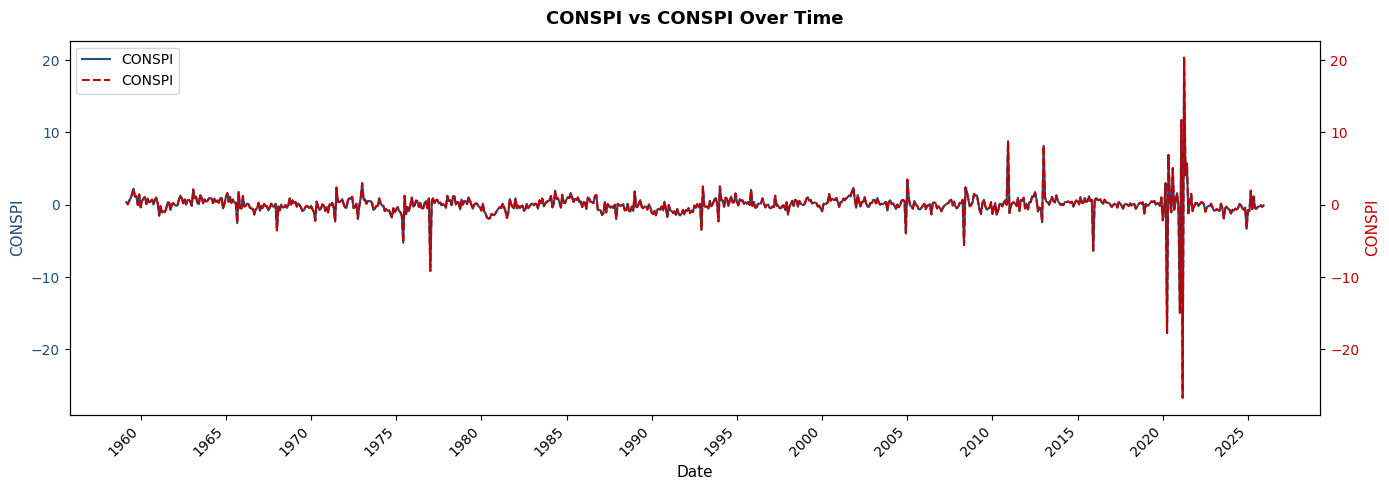

In [140]:
plot_fredmd_dual(macro_fred_df, var1="CONSPI", var2="CONSPI")